# **Ejercicio Final - Big Data en la Nube**

### **- Instrucciones del examen**
Para la realización de este examen será necesario que completes seis tareas:



*   Tarea 1 _ Acceso a los archivos .csv y revisión del contenido
*   Tarea 2 _ Visualización gráfica a través de Pandas y Seaborn
*   Tarea 3 _ Visualización gráfica con Spark
*   Tarea 4 _ Relación entre variables
*   Tarea 5 _ Modelos estadísticos
*   Tarea 6 _ Entrenamiento del modelo con datos recientes

Cada una de las tareas se compondrá de varios apartados. Es importante tener en cuenta que las tareas presentan una dependencia entre sí, por lo que si las primeras no se realizan correctamente automáticamente el resto estarán mal de forma automática.

A lo largo del cuaderno, encontrarás indicaciones que te ayudarán a comprender qué debes realizar en cada tarea de forma general y en cada uno de sus apartados de forma específica. Por lo que deberás completar las celdas de código situadas debajo de las celdas de texto que contendrán los enunciados, siguiendo las instrucciones que se te han proporcionado en ellos.

En ocasiones, es posible que se presenten funcionalidades que no se han visto durante el curso, para que tengáis que investigar su uso, pero no te preocupes ya que serán sencillas.

***Presta especial atención a cómo se te pide resolver cada apartado.*** En algunos casos se te pedirá que uses PySpark. En otros casos se te pedirá que uses Pandas. Utiliza siempre la tecnología que se solicite para evitar penalizaciones en la nota final del trabajo.

<br>

### **- Comentarios y sugerencias**
A lo largo del trabajo podrás ir probando el código que estás desarrollando, no dudes en probarlo tantas veces como necesites.

Recuerda que este es un trabajo sin límite de tiempo y que aunque deberás entregarlo dentro del período activo de tu matrícula, podrás dedicarle todo el tiempo que necesites para resolver cada uno de los apartados solicitados.

En caso de dudas recuerda que podrás:


*   Repasar el temario teórico y audiovisual
*   Revisar la documentación oficial de la API de PySpark, lo que te permitirá consultar qué funciones deberías utilizar al trabajar con dataframes
*   Ponerte en contacto con los docentes del curso a través de la mensajería para que te ayuden a comprender aquellos apartados que te causen más dificultad. Eso sí, recuerda que este trabajo es un examen y por tanto, los docentes nunca podrán facilitarte respuestas directas.

<br>


### **- Configuración Previa**
Antes de comenzar el ejercicio, será necesario que ejecutes el siguiente bloque de código, ya que será esencial para poder configurar Spark en tu sesión de Google Colab y poder trabajar en el ejercicio correctamente.

<br>

***Recuerda que:***

1.   Recuerda que para que el contenido del cuaderno se pueda ejecutar será necesario conectarse a un cluster (recurso computacional) y para ello deberás hacer clic en la opción llamada "Conectar" (o "Volver a conectar" si habías desconectado el cluster) situada en la parte superior derecha del cuaderno.

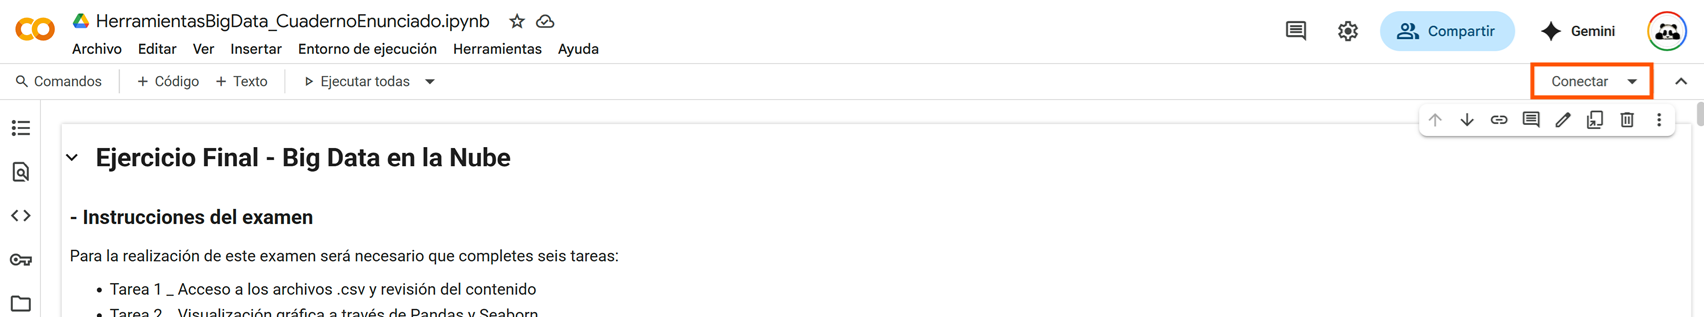

<br>

2.   Para ejecutar el código de una celda será necesario que hagas clic sobre el símbolo de "*reproducir*" situado en la parte superior izquierda de cada celda de código.

<br>

3.   La ejecución de algunas celdas de código (como las de la configuración) pueden tardar algo de tiempo en ejecutarse (hasta 5 o 10 minutos aproximadamente).

<br>

4.   A veces, la ejecución de las celdas puede fallar por problemas durante la carga de los recursos, en ese caso sería recomendable desconectar el cluster (recurso que permite ejecutar el código en la nube), eliminando el contenido del entorno de ejecución y volver a realizar la conexión al cluster nuevamente.

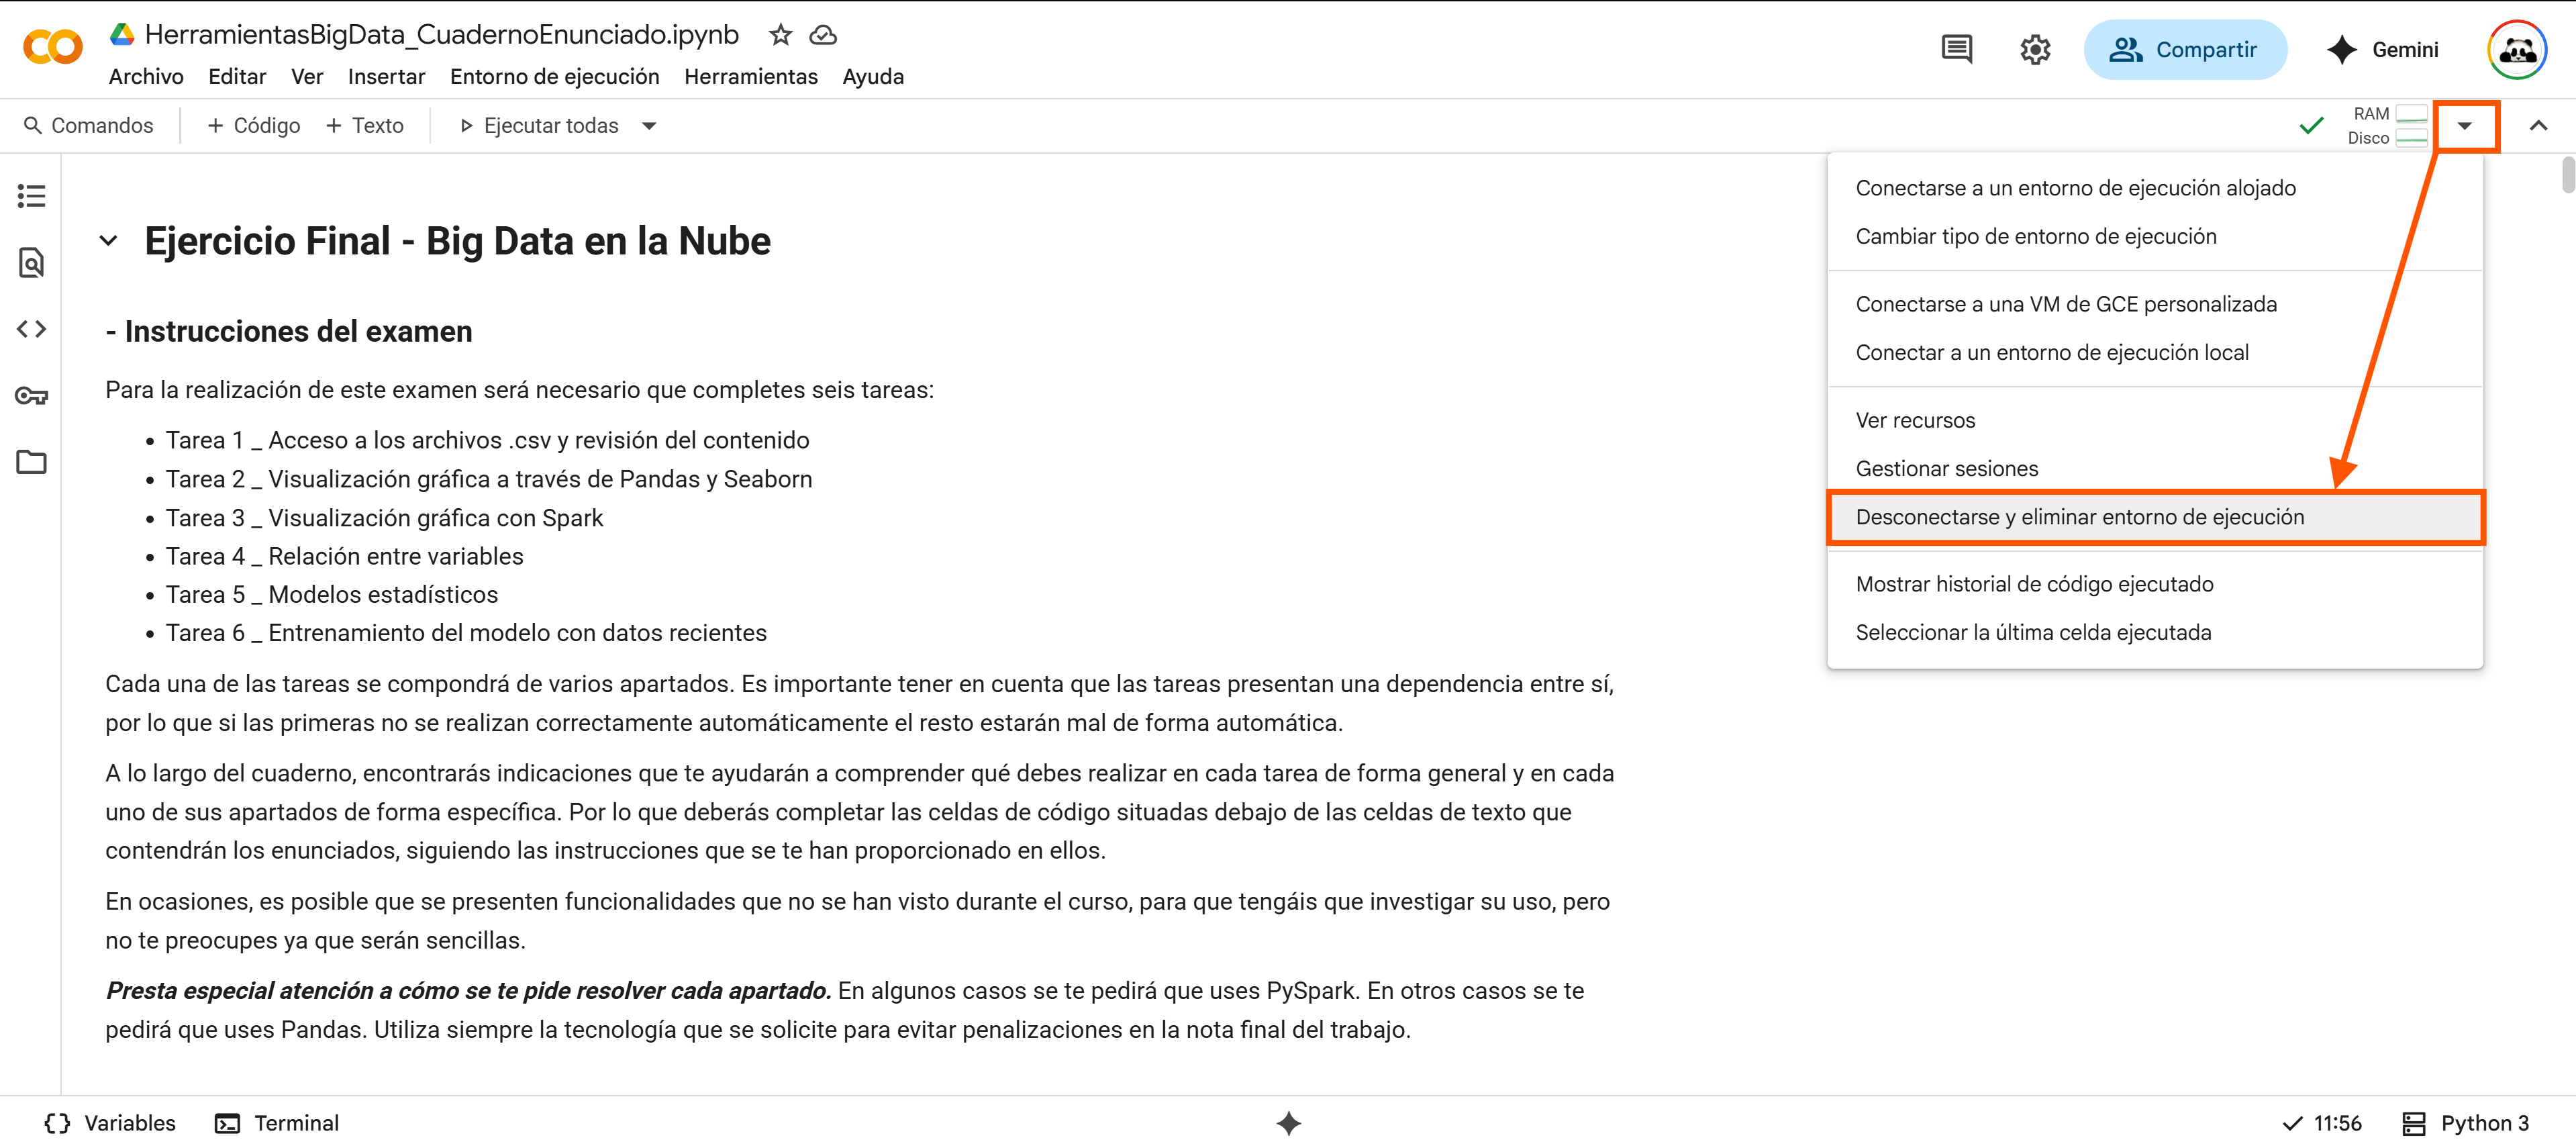



<br>

***¡Ánimo!***

<br>

In [1]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
# --- CONFIGURACIÓN INICIAL DE SPARK EN GOOGLE COLAB ---

# Instalación de Java
!apt-get install openjdk-17-jdk-headless -qq > /dev/null

# Descarga de Spark desde el archivo oficial de Apache
!wget -q https://archive.apache.org/dist/spark/spark-4.0.0/spark-4.0.0-bin-hadoop3.tgz
!tar -xzf spark-4.0.0-bin-hadoop3.tgz

# Instalación de librerías necesarias
!pip install -q findspark
# Es pragmático relajar las versiones de fsspec y gcsfs para evitar conflictos de dependencias en Colab
!pip install -q fsspec gcsfs s3fs
!pip install -q pyspark==4.0.0

# Configuración del entorno
import os
# Apuntamos a la nueva ruta de Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
# Apuntamos a la carpeta recién extraída de Spark 4.0.0
os.environ["SPARK_HOME"] = "/content/spark-4.0.0-bin-hadoop3"

import findspark
findspark.init()

# Creación de la sesión de Spark
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Herramientas Big Data - Ejercicio Final sobre el mercado eléctrico") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()

print("SparkSession creada correctamente con la versión:")
print(spark.version)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
SparkSession creada correctamente con la versión:
4.0.0


***Instalación de seaborn***
<br>
Una vez se han instalado Java y Spark en tu sesión de CodeLab será necesario instalar Seaborn y mostrar su versión disponible. Por ello, deberás ejecutar también el siguiente bloque de código.

In [2]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
!pip install seaborn --upgrade

import seaborn as sns

# Mostramos la versión disponible de seaborn
print(sns.__version__)

0.13.2


## **Tarea 1 - Acceso a los archivos .csv y revisión del contenido**
Tu primera tarea será completar los siguientes bloques de código para crear tres datasets dónde cargar los datos de los tres ficheros .csv:

*   Fichero de precios: `precio_md.csv`
*   Fichero de previsión de la demanda: `prvdem.csv`
*   Fichero de la previsión de generación eólica: `preveol.csv`

<br>

***Consejo:*** Presta especial atención a los parámetros:`inferSchema`, `header` y `sep`.

<br>


In [3]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
# Este bloque se encargará de importar algunas funcionalidades básicas
import pyspark.sql.functions as F
from pyspark.sql.functions import col, to_date

En el siguiente bloque de código se mostrará cómo podrás vincular Google Colab con Google Drive para poder utilizar los archivos .csv

***Nota:*** Si no aceptas los permisos de acceso que permiten conectar ambas plataformas entre sí, el acceso a los archivos no será posible.

In [4]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO y ACEPTA LOS PERMISOS
# Este bloque de código te permitirá acceder al Google Drive asociado a tu cuenta de Google.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


En este bloque de código se te mostrará como podrás:

1.   Acceder al archivo csv llamado `precio_md.csv` situado en una carpeta llamada bigdata_csv dentro de tu cuenta de Google Drive.

2.   Establecer las opciones de configuración del archivo .csv (si deseas que se identifique el tipo de dato asociado a cada columna de forma automática, si la primera fila de datos corresponde al encabezado de las columnas, cuál es el delimitador de las columnas de datos)

3.   Crear un dataframe de Spark con los datos del archivo .csv, haciendo uso de las opciones de configuración del archivo.

<br>

***Recuerda*** completar el resto de apartados siguiendo estos pasos.



In [5]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
# Localización del archivo "precio_md.csv" en Google Drive e indicar su extensión
file_location = "/content/drive/MyDrive/Trabajo y formaciones/MASTER BIG DATA + CLOUD COMPUTING - DAVANTE: 2025/Curso/3. Herramientas Big Data/Trabajo Final/bigdata_csv/precio_md.csv"
file_type = "csv"

# Opciones del archivo CSV
infer_schema = "true"
first_row_is_header = "true"
delimiter = "\t"

# Creación de un dataframe con el contenido del archivo CSV haciendo uso de sus opciones
precio_md = spark.read.format(file_type) \
              .option("inferSchema", infer_schema) \
              .option("header", first_row_is_header) \
              .option("sep", delimiter) \
              .load(file_location)

# Mostrar las primeras cinco columnas de contenido del dataframe
precio_md.show(5)

+----------+----+---------+
|     fecha|hora|precio_md|
+----------+----+---------+
|2015-01-01|   1|     50.1|
|2015-01-01|   2|     48.1|
|2015-01-01|   3|    47.33|
|2015-01-01|   4|    42.27|
|2015-01-01|   5|    38.41|
+----------+----+---------+
only showing top 5 rows


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Localización del archivo "prvdem.csv" en Google Drive e indicar su extensión
file_location = "/content/drive/MyDrive/Trabajo y formaciones/MASTER BIG DATA + CLOUD COMPUTING - DAVANTE: 2025/Curso/3. Herramientas Big Data/Trabajo Final/bigdata_csv/prvdem.csv"
file_type = "csv"
# CSV options
infer_schema = "true"
first_row_is_header = "true"
delimiter = "\t"
# Creación de un dataframe con el contenido del archivo CSV haciendo uso de sus opciones
prev_demanda = spark.read.format(file_type) \
              .option("inferSchema", infer_schema) \
              .option("header", first_row_is_header) \
              .option("sep", delimiter) \
              .load(file_location)

# Mostrar las primeras cinco columnas de contenido del dataframe
prev_demanda.show(5)

+----------+----+------------+
|     fecha|hora|prev_demanda|
+----------+----+------------+
|2015-01-01|   1|       26460|
|2015-01-01|   2|       25369|
|2015-01-01|   3|       23973|
|2015-01-01|   4|       22559|
|2015-01-01|   5|       21603|
+----------+----+------------+
only showing top 5 rows


In [8]:
# Localización del archivo "preveol.csv" en Google Drive e indicar su extensión
file_location = "/content/drive/MyDrive/Trabajo y formaciones/MASTER BIG DATA + CLOUD COMPUTING - DAVANTE: 2025/Curso/3. Herramientas Big Data/Trabajo Final/bigdata_csv/preveol.csv"
file_type = "csv"
# CSV options
infer_schema = "true"
first_row_is_header = "true"
delimiter = "\t"
# Creación de un dataframe con el contenido del archivo CSV haciendo uso de sus opciones
prev_eolica = spark.read.format(file_type) \
              .option("inferSchema", infer_schema) \
              .option("header", first_row_is_header) \
              .option("sep", delimiter) \
              .load(file_location)

# Mostrar las primeras cinco columnas de contenido del dataframe
prev_eolica.show(5)

+----------+----+-----------+
|     fecha|hora|prev_eolica|
+----------+----+-----------+
|2015-01-01|   1|       4996|
|2015-01-01|   2|       4603|
|2015-01-01|   3|       4230|
|2015-01-01|   4|       3976|
|2015-01-01|   5|       3802|
+----------+----+-----------+
only showing top 5 rows


### **Apartado 1.A**
A través de Spark, muestra la estructura del dataframe, es decir, la cantidad de columnas y el tipo de dato que tienen asociado.

***Sugerencia:*** Dependiendo del entorno dónde ejecutes el código la función `display()` mostrará unicamente la estructura del dataframe o podrá tener una versión enriquecida donde se muestren opciones gráficas o su contenido en forma de tabla.

En concreto, en Google Colabs, esta función solo mostrará la estructura del dataframe.

In [9]:
# Muestra la estructura del dataframe de los precios
display(precio_md)

DataFrame[fecha: date, hora: int, precio_md: double]

In [10]:
# Muestra la estructura del dataframe  de la previsión de demanda
display(prev_demanda)

DataFrame[fecha: date, hora: int, prev_demanda: int]

In [11]:
# Muestra la estructura del dataframe  de la previsión eólica
display(prev_eolica)

DataFrame[fecha: date, hora: int, prev_eolica: int]

### **Apartado 1.B**
Imprime y revisa los esquemas de cada dataframe. Comprueba el tipo de dato asociado a cada una de las columnas.

*   ¿Tienen el tipo adecuado a los valores que ves (fechas, numéricos...)? ¿O son todas de tipo texto?

*   ¿Ajustaste la opción inferSchema al cargar los datos? Si no es así, ajusta y carga los datos para que tengan asociado el tipo de dato adecuado al que les corresponda (tipo fecha, tipo numérico, ...)

<br>

***Alternativa:*** Si no ajustaste la opción *inferSchema* y no quieres volver a cargar los datos, puedes tratar de convertir el tipo de las columnas. Para modificar el tipo de una columna, existe el método cast().

Existen métodos específicos para convertir a tipo date o timestamp. Revisa la documentación de la API de Spark.

In [12]:
# Imprime y revisa el esquema de los datos de precios
precio_md.printSchema()

root
 |-- fecha: date (nullable = true)
 |-- hora: integer (nullable = true)
 |-- precio_md: double (nullable = true)



In [13]:
# Imprime y revisa el esquema de los datos de previsión de demanda
prev_demanda.printSchema()

root
 |-- fecha: date (nullable = true)
 |-- hora: integer (nullable = true)
 |-- prev_demanda: integer (nullable = true)



In [14]:
# Imprime y revisa el esquema de los datos de previsión de generación eólica
prev_eolica.printSchema()

root
 |-- fecha: date (nullable = true)
 |-- hora: integer (nullable = true)
 |-- prev_eolica: integer (nullable = true)



### **Apartado 1.C**
Genera el resumen estadístico de cada dataframe.



*   ¿Cuáles son los valores medios de los precios?
*   ¿Y de la demanda prevista?
*   ¿ Y de la generación eólica prevista?
*   ¿Cuál es el rango de valores de cada una de estas variables?

In [15]:
# Muestra el resumen estadístico de los datos de precios
precio_md.summary().show()

# Respuestas:
    # Valor medio del precio = 49.87
    # Rango: Rango de 99.93 / min 2.06 / max 101.99

+-------+------------------+------------------+
|summary|              hora|         precio_md|
+-------+------------------+------------------+
|  count|             35064|             35064|
|   mean| 12.50011407711613| 49.87434120465047|
| stddev|6.9224830205847745|14.618899685404438|
|    min|                 1|              2.06|
|    25%|                 6|             41.49|
|    50%|                12|             50.52|
|    75%|                18|             60.53|
|    max|                25|            101.99|
+-------+------------------+------------------+



In [16]:
# Muestra el resumen estadístico de los datos de previsión de demanda
prev_demanda.summary().show()

# Respuestas:
    # Valor medio del precio = 28706.94
    # Rango: Rango de 24044 / min 17599 / max 41643

+-------+-----------------+------------------+
|summary|             hora|      prev_demanda|
+-------+-----------------+------------------+
|  count|            35064|             35064|
|   mean|12.50011407711613|28706.948009354324|
| stddev|6.922483020584796| 4592.023271032872|
|    min|                1|             17599|
|    25%|                6|             24795|
|    50%|               12|             28889|
|    75%|               18|             32219|
|    max|               25|             41643|
+-------+-----------------+------------------+



In [17]:
# Muestra el resumen estadístico de los datos de previsión de generación eólica
prev_eolica.summary().show()

# Respuestas:
    # Valor medio del precio = 5470.06
    # Rango: Rango de 17385 / min 0 / max 17385

+-------+-----------------+------------------+
|summary|             hora|       prev_eolica|
+-------+-----------------+------------------+
|  count|            35064|             35064|
|   mean|12.50011407711613| 5470.068702943189|
| stddev|6.922483020584796|3164.3737013165523|
|    min|                1|                 0|
|    25%|                6|              2974|
|    50%|               12|              4871|
|    75%|               18|              7379|
|    max|               25|             17385|
+-------+-----------------+------------------+



## **Tarea 2 - Visualización gráfica a través de Pandas y Seaborn**
PySpark nos permite convertir un dataframe de Spark a un dataframe de Pandas, y así poder trabajar con las funcionalidades y librerías disponibles con Pandas.

### **Apartado 2.A**
Utiliza el método `df.toPandas()` para transformar un dataframe de Spark a Pandas.

In [18]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
# Este bloque de código genera un dataframe de Pandas del dataframe de Spark.
precio_md_pd = precio_md.toPandas()

Ahora exporta los dataframes restantes (demanda y previsión eólica) de Spark a Pandas. Recuerda utilizar nombres de variables diferentes para poder seguir trabajando con las versiones de Spark más adelante sin que haya confusión.

In [19]:
# Dataframe de la previsión de la demanda de Spark a Pandas
prev_demanda_pd = prev_demanda.toPandas()

In [20]:
# Dataframe de la previsión eólica de Spark a Pandas
prev_eolica_pd = prev_eolica.toPandas()

### **Apartado 2.B**
Genera el resumen estadístico usando las funciones de Pandas con estos dataframes.
¿Concuerdan los valores medios y rangos con los resultados usando Spark?

In [21]:
# Resumen estadístico de los datos de precios con Pandas
precio_md_pd.describe()

,hora,precio_md
count,35064.000000,35064.000000
mean,12.500114,49.874341
std,6.922483,14.618900
min,1.000000,2.060000
25%,6.750000,41.490000
50%,12.500000,50.520000
75%,18.250000,60.530000
max,25.000000,101.990000


In [22]:
# Resumen estadístico de los datos de previsión de demanda con Pandas
prev_demanda_pd.describe()

,hora,prev_demanda
count,35064.000000,35064.000000
mean,12.500114,28706.948009
std,6.922483,4592.023271
min,1.000000,17599.000000
25%,6.750000,24796.750000
50%,12.500000,28891.000000
75%,18.250000,32221.000000
max,25.000000,41643.000000


In [23]:
# Resumen estadístico de los datos de previsión eólica con Pandas
prev_eolica_pd.describe()

,hora,prev_eolica
count,35064.000000,35064.000000
mean,12.500114,5470.068703
std,6.922483,3164.373701
min,1.000000,0.000000
25%,6.750000,2975.000000
50%,12.500000,4872.000000
75%,18.250000,7380.250000
max,25.000000,17385.000000


### **Apartado 2.C**
Ahora utilizarás los dataframes de Pandas que has creado para visualizar distintos gráficos usando Seaborn.

Veamos un ejemplo. Vamos a calcular el precio promedio diario de cada fecha usando Pandas, y después vamos a crear un gráfico para ver la evolución temporal de este precio medio diario usando Seaborn.

Ejecuta las siguientes celdas de código para comprobar el funcionamiento.

<Axes: xlabel='fecha', ylabel='precio_md'>

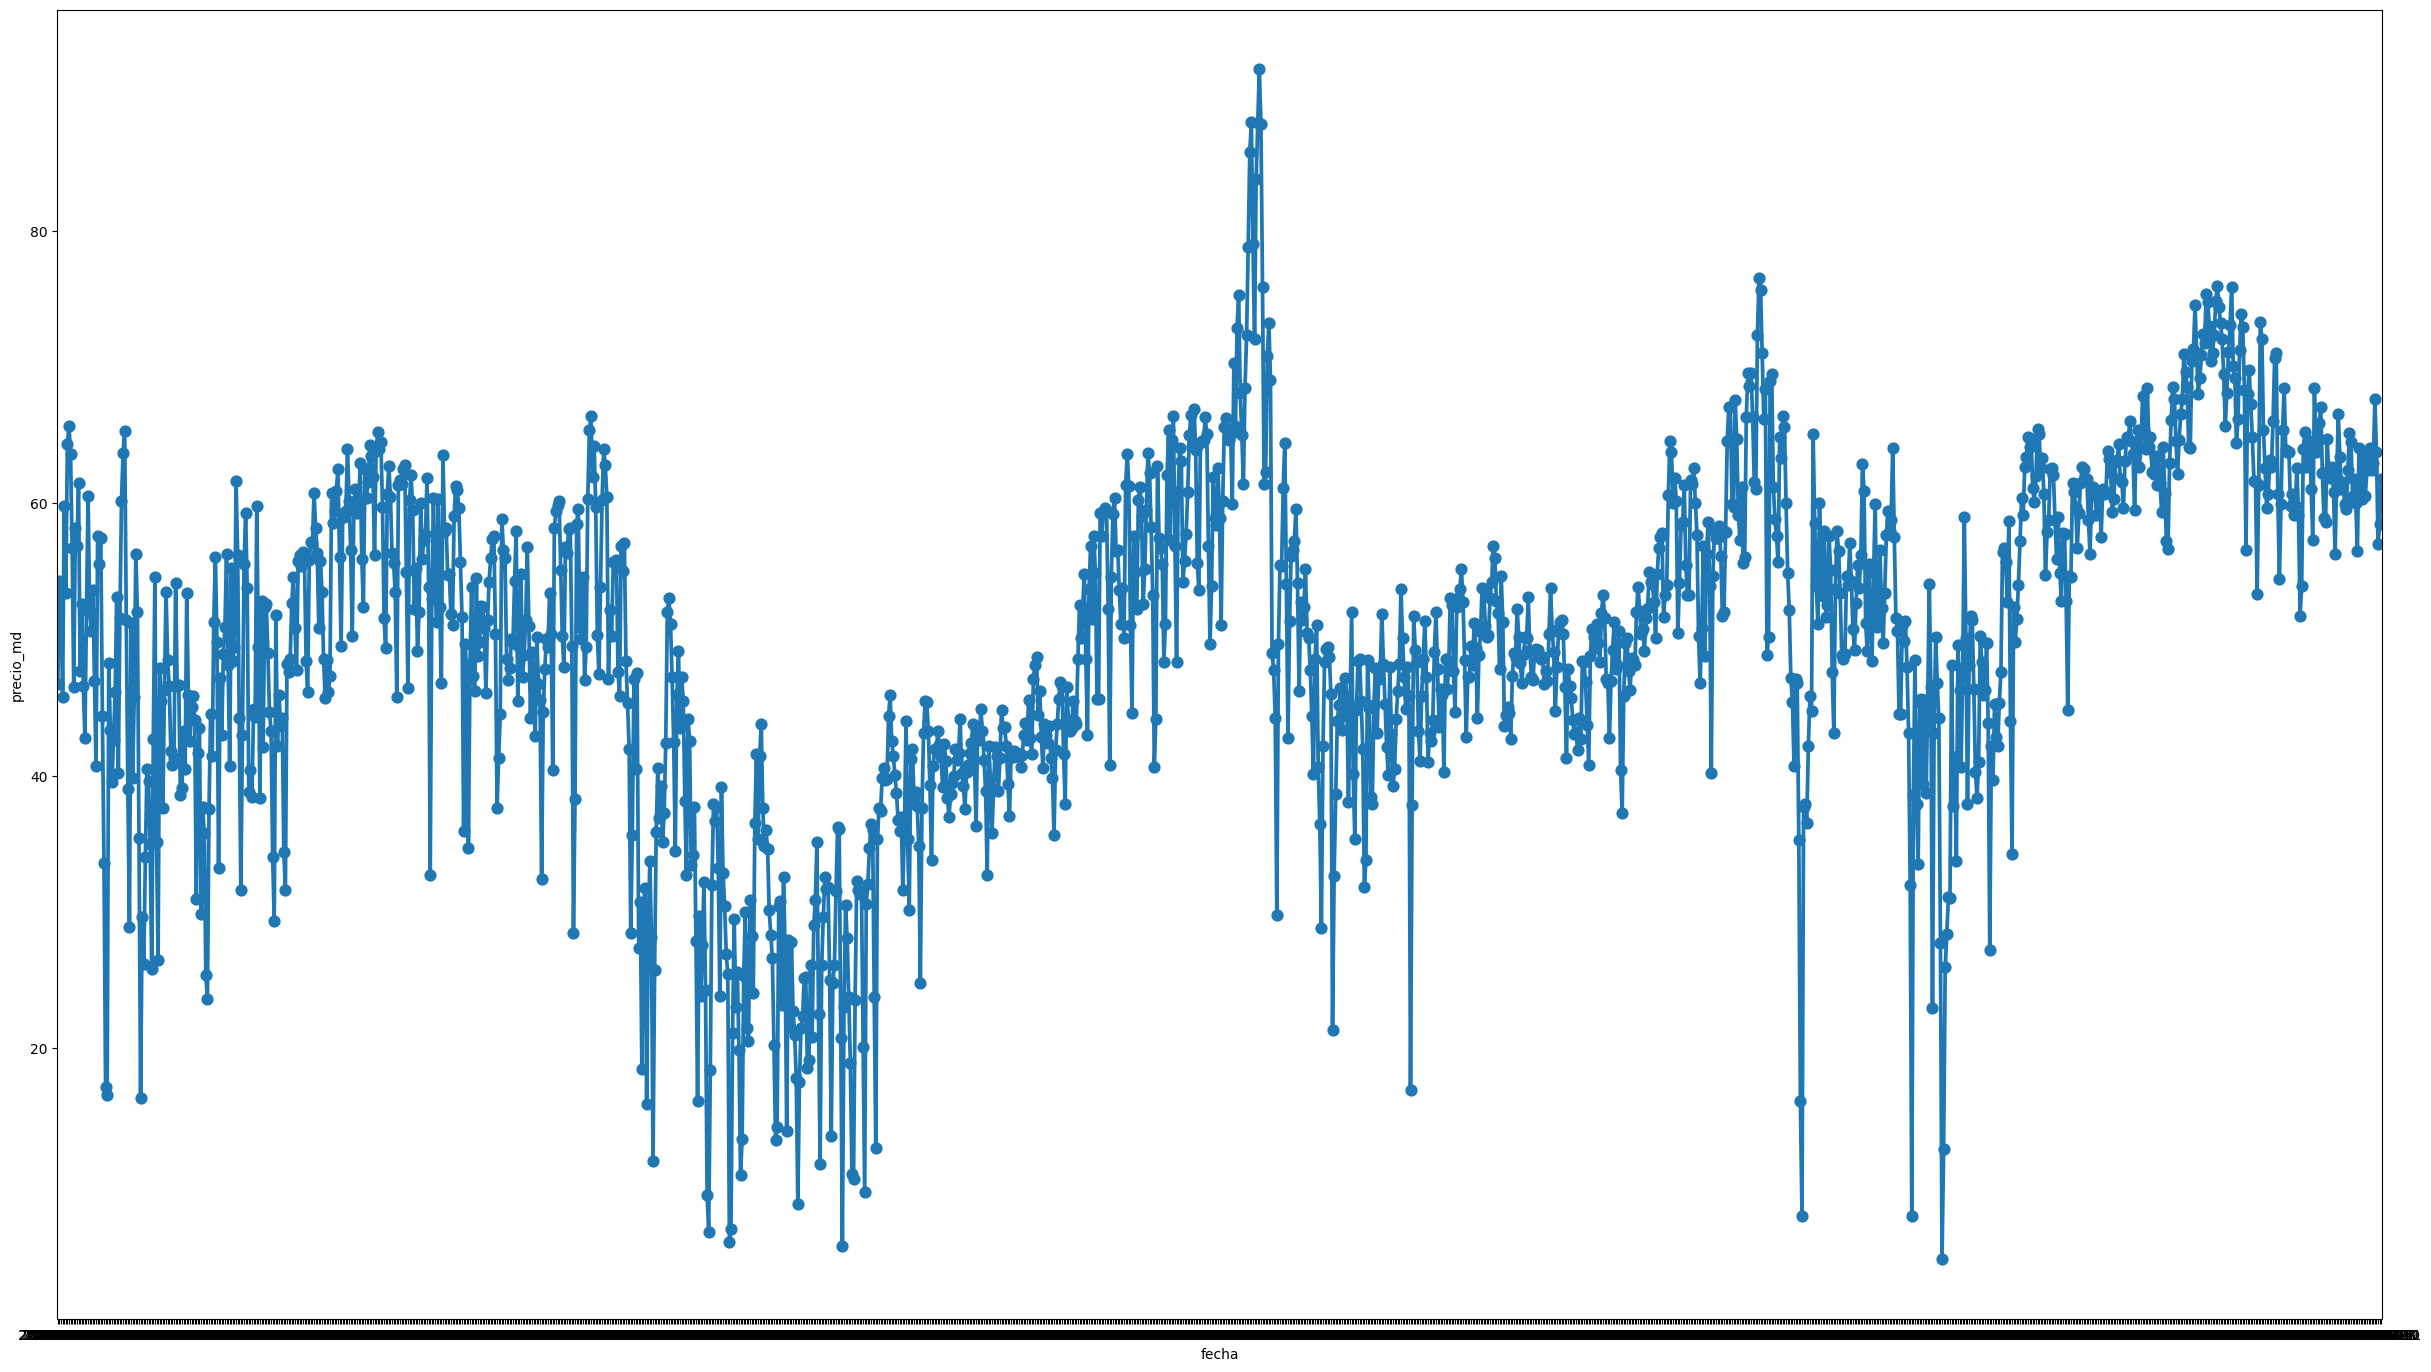

In [24]:
# EJECUTA EL SIGUIENTE BLOQUE DE CÓDIGO
# Cargamos las librerias NumPy y Pandas
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

# Cargamos Matplotlib y Seaborn
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos el precio promedio diario usando Pandas
precio_medio_diario = precio_md_pd.groupby("fecha", as_index=False)["precio_md"].aggregate("mean")

# Inicializamos un gráfico en blanco de Seaborn para poder pintarlo
plt.figure()

# Definimos el gráfico - Usamos un gráfico de puntos
plot_precio_md = sns.pointplot(x=precio_medio_diario["fecha"], y=precio_medio_diario["precio_md"] ,data=precio_medio_diario)

# Opcional: Modificamos el tamaño del gráfico
plot_precio_md.figure.set_size_inches(30,17)

# Utilizamos display() para pintar el gráfico
display(plot_precio_md)

Siguiendo el ejemplo anterior, calcula el promedio diario de la previsión de la demanda horaria utilizando Pandas. Después, crea un gráfico con Seaborn para ver la evolución temporal de la demanda.

<Axes: xlabel='fecha', ylabel='prev_demanda'>

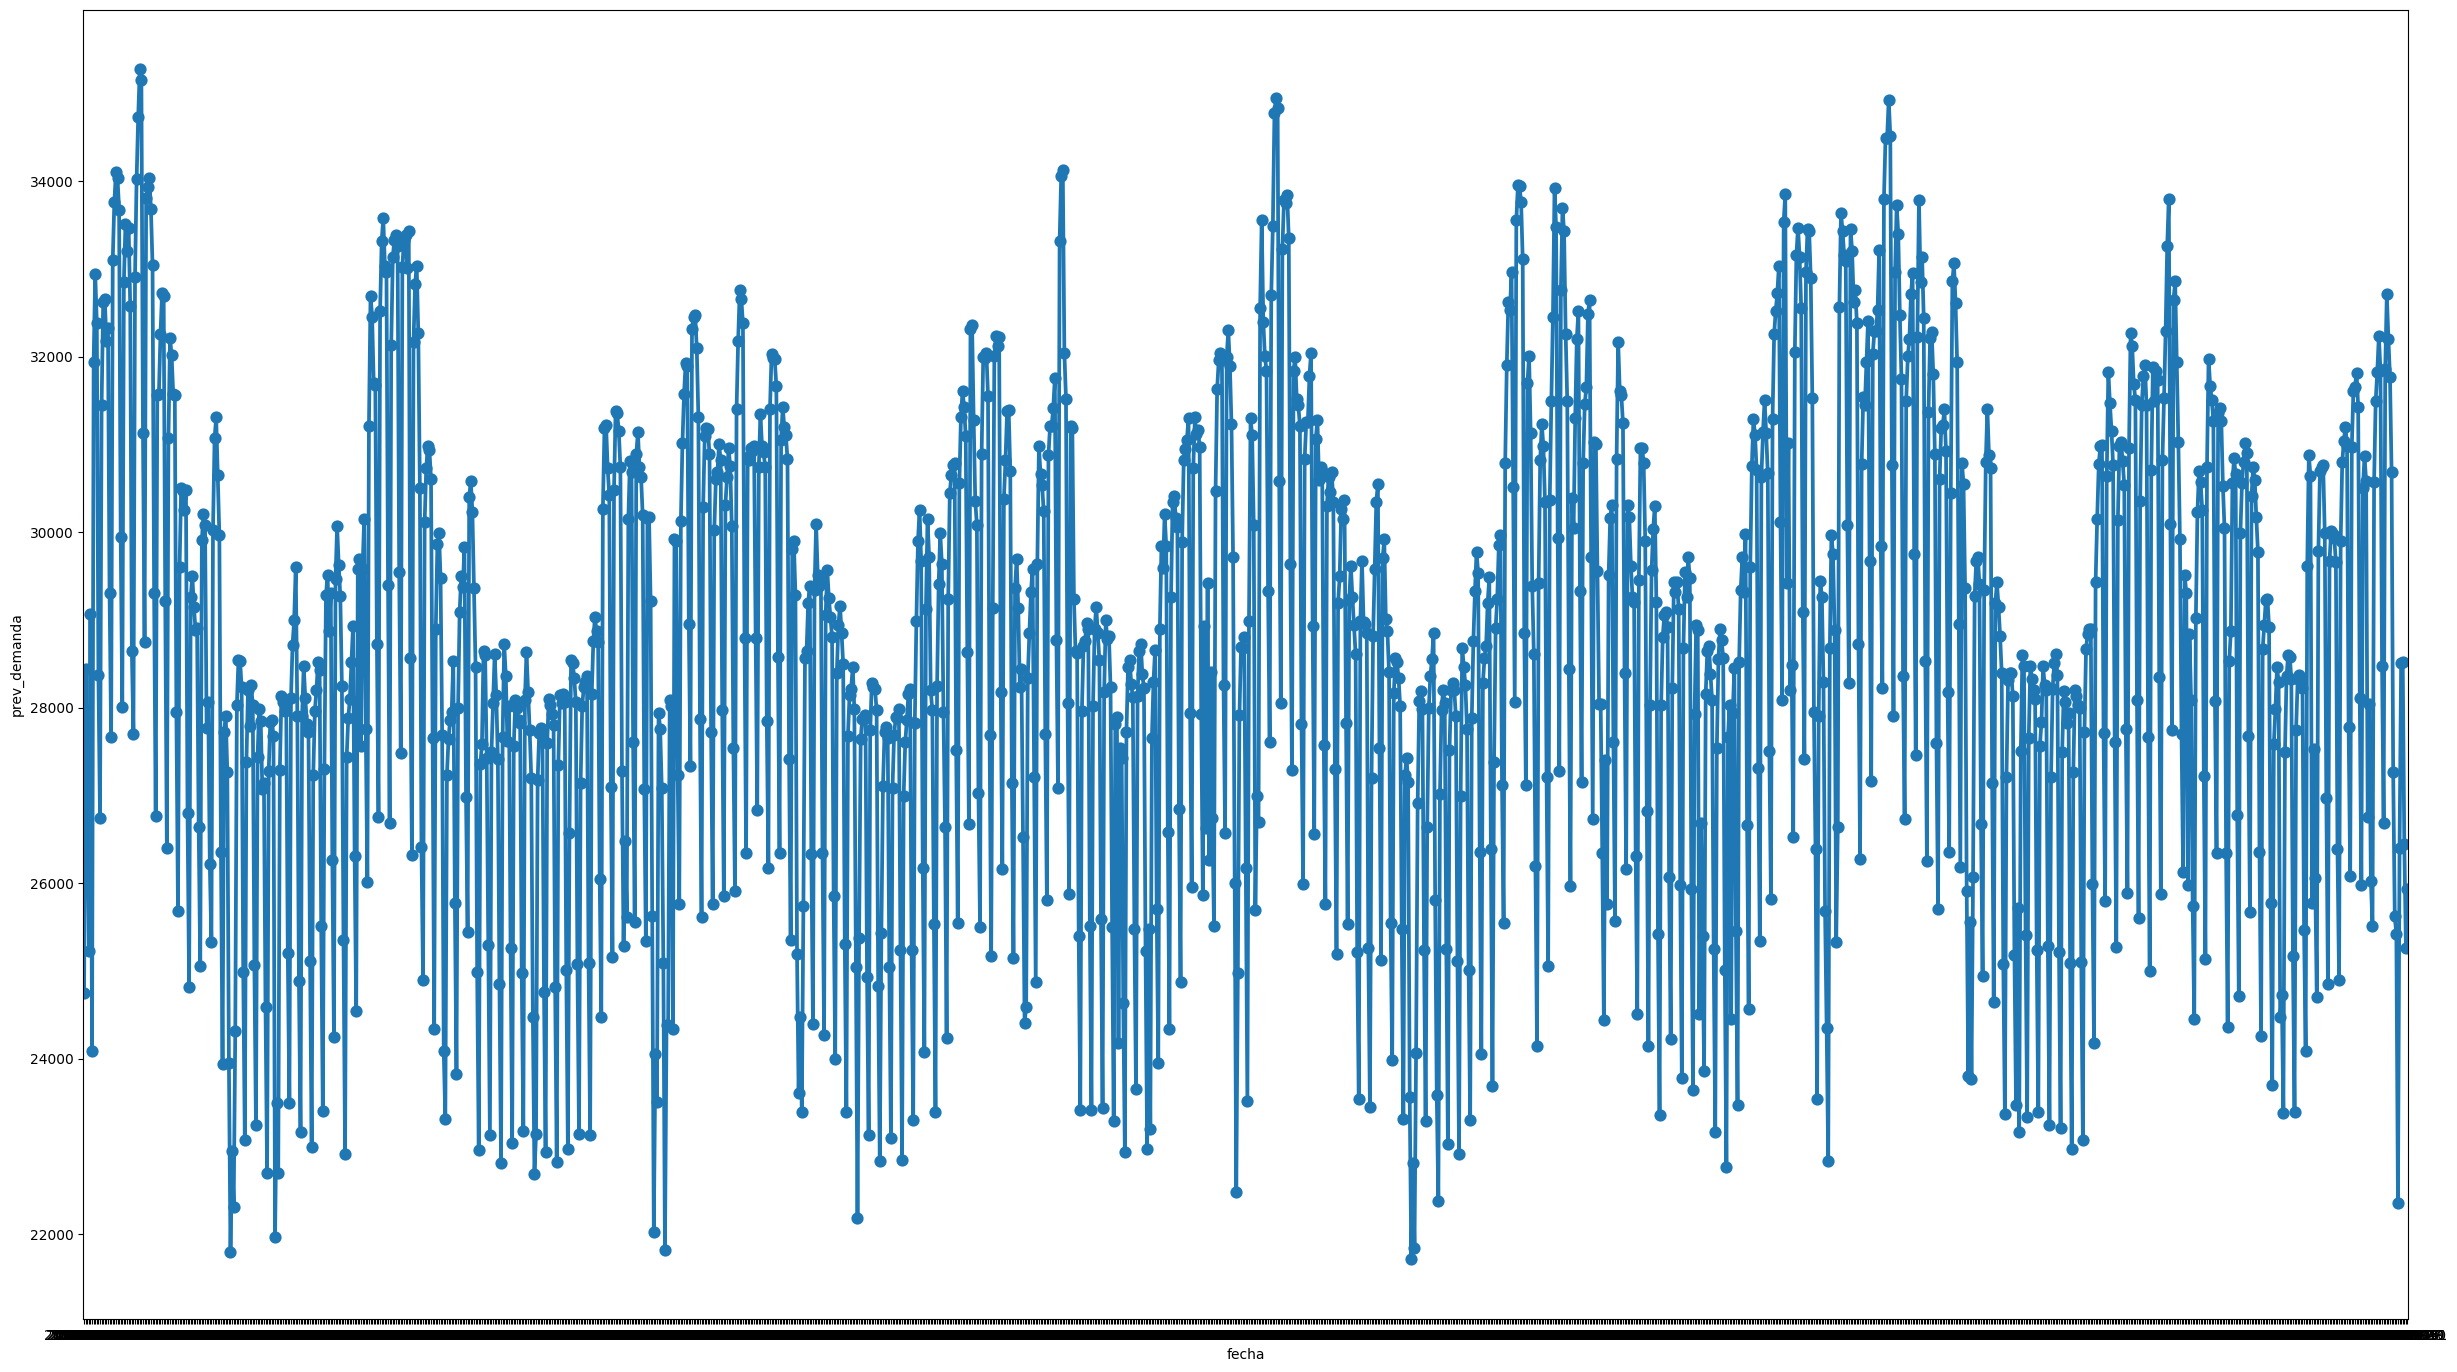

In [25]:
# Inicializamos un gráfico en blanco de Seaborn para poder pintarlo
plt.figure()

# Completa el código

# 1. Calculamos la prevision de demanda promedio diario usando Pandas
prev_demanda_diario = prev_demanda_pd.groupby("fecha", as_index =False)["prev_demanda"].aggregate("mean")

# 2. Definimos el grafico de puntos mediante sns.poinplot()
plot_prev_demanda = sns.pointplot(x=prev_demanda_diario["fecha"], y=prev_demanda_diario["prev_demanda"], data=prev_demanda_diario)

# 3. Modificamos el tamaño del grafico (al mismo tamaño que el anterior)
plot_prev_demanda.figure.set_size_inches(30,17)

# 4. Pintamos el grafico con display()
display(plot_prev_demanda)

Ahora calcula el promedio diario de la previsión eólica horaria usando Pandas. Después, crea otro gráfico con Seaborn para ver la evolución temporal de la eolicidad prevista.

<Axes: xlabel='fecha', ylabel='prev_eolica'>

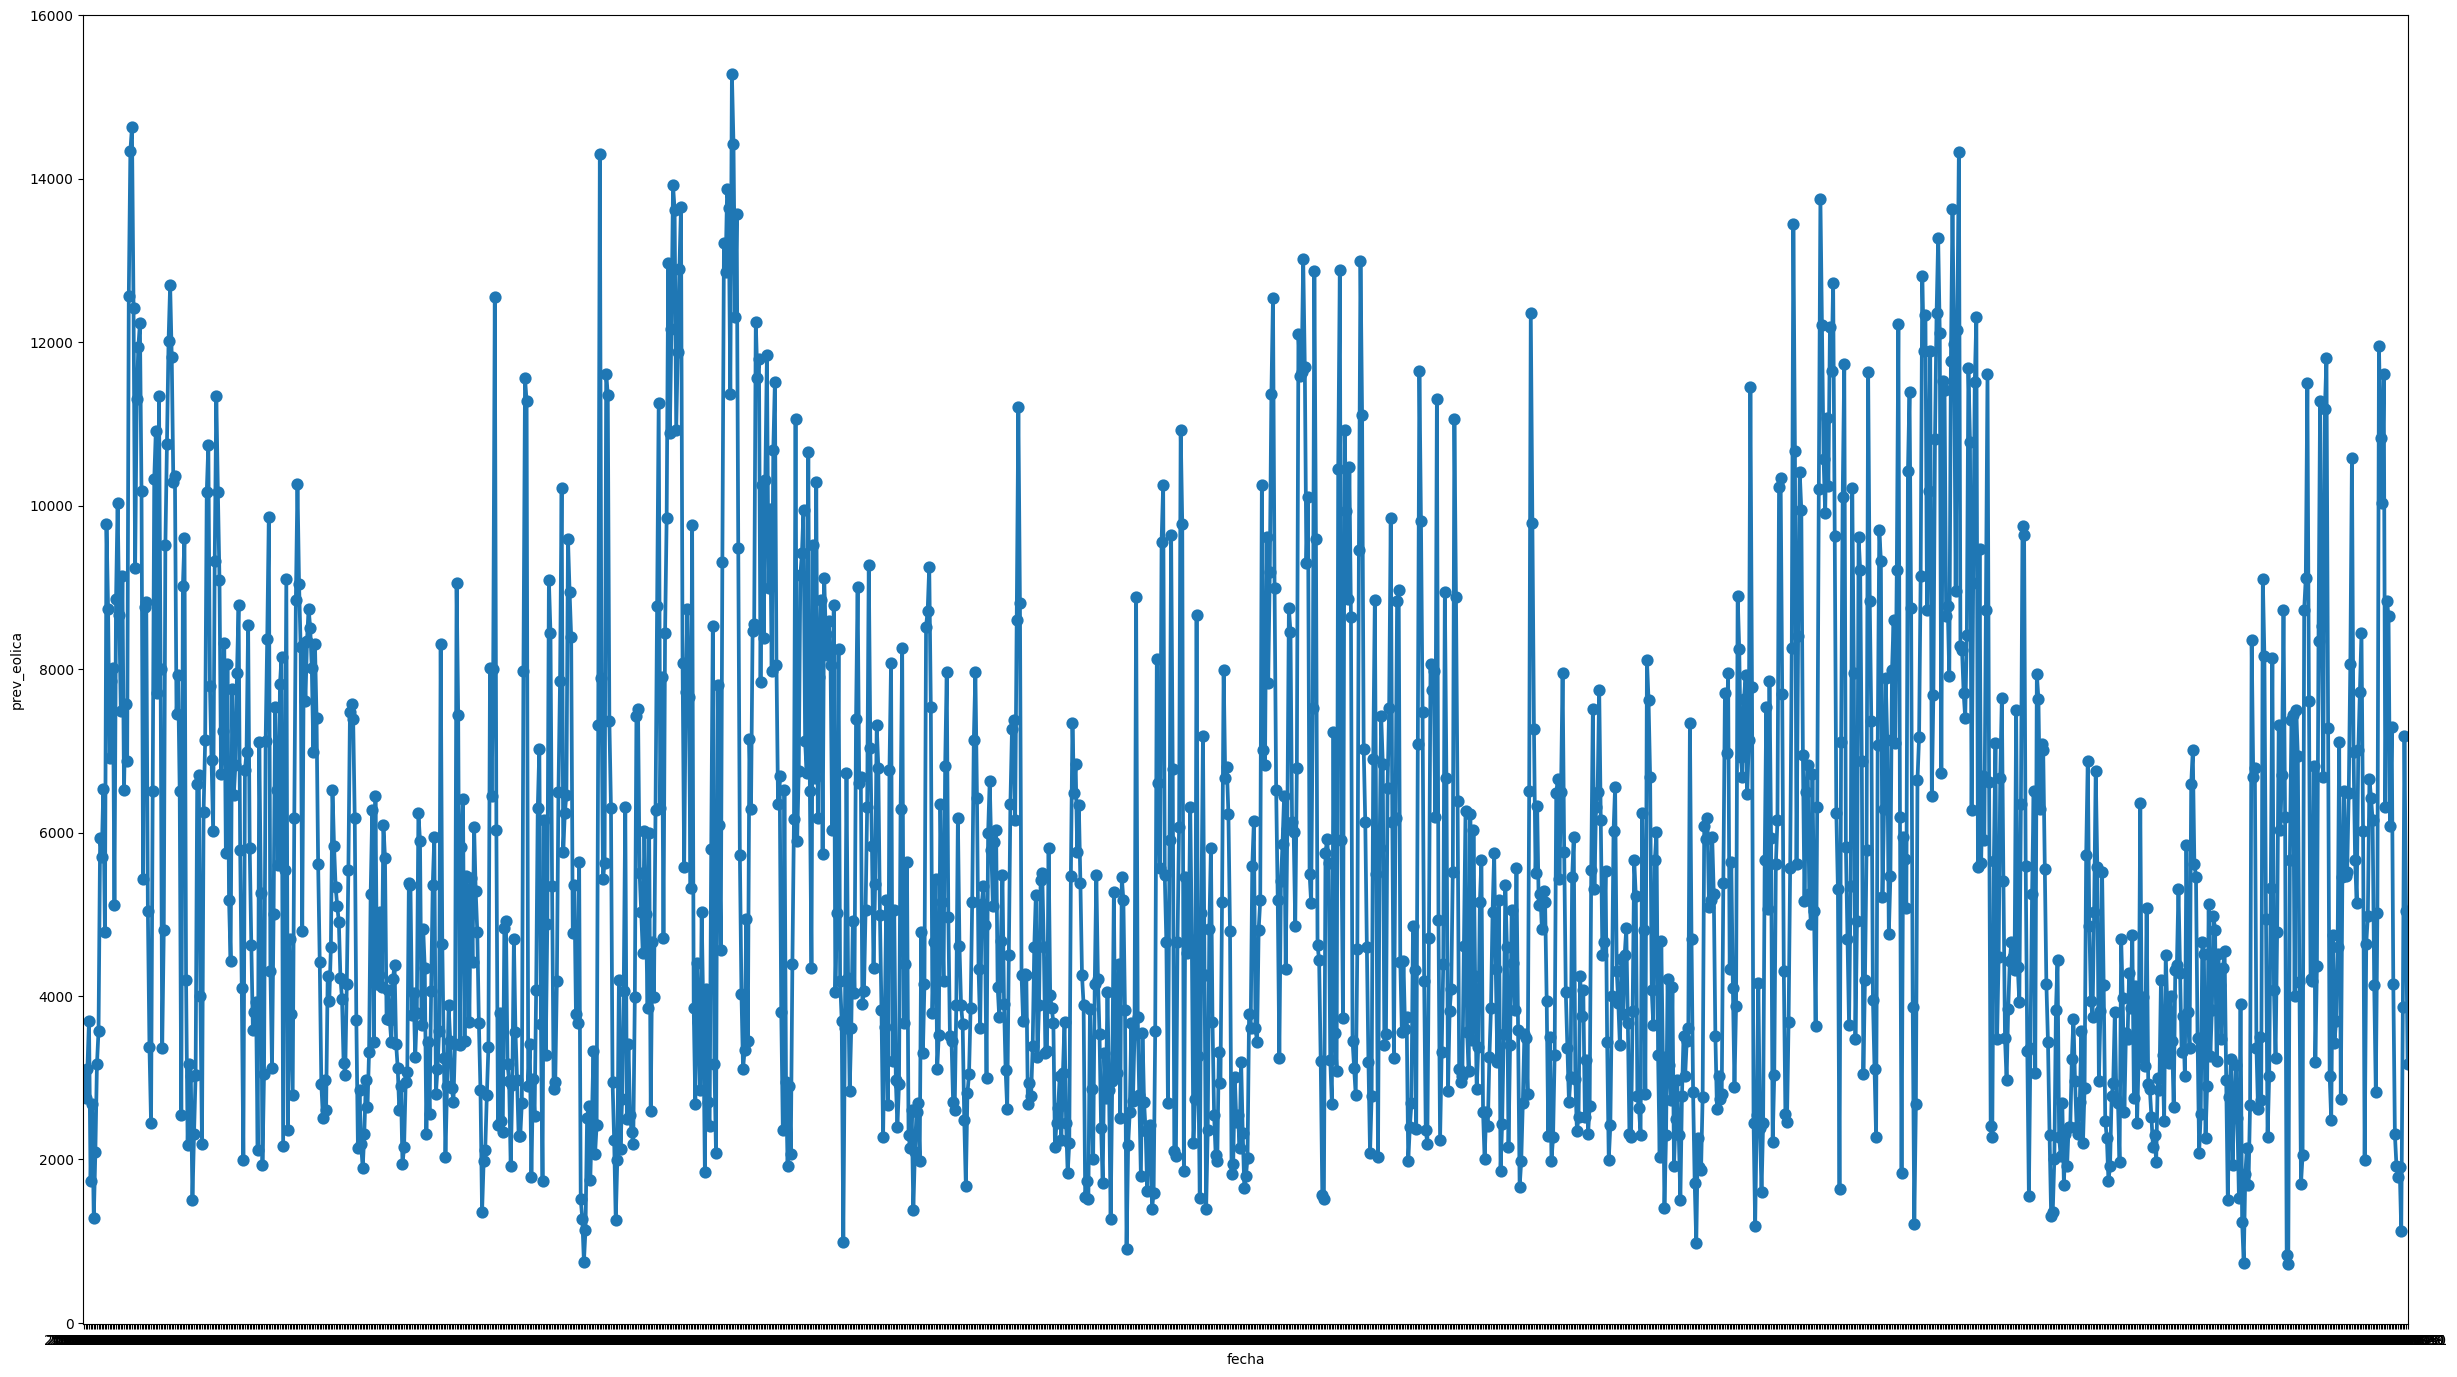

In [26]:
# Inicializamos un gráfico en blanco de Seaborn para poder pintarlo
plt.figure()

# Completa el código

# 1. Calculamos la prevision de demanda promedio diario usando Pandas
prev_eolica_diario = prev_eolica_pd.groupby("fecha", as_index =False)["prev_eolica"].aggregate("mean")

# 2. Definimos el grafico de puntos mediante sns.poinplot()
plot_eolica = sns.pointplot(x=prev_eolica_diario["fecha"], y=prev_eolica_diario["prev_eolica"], data=prev_eolica_diario)

# 3. Modificamos el tamaño del grafico (al mismo tamaño que el anterior)
plot_eolica.figure.set_size_inches(30,17)

# 4. Pintamos el grafico con display()
display(plot_eolica)

### **Apartado 2.D**
Ahora veamos los perfiles horarios. Vamos a generar un gráfico de barras con el precio medio horario, puedes generar un gráfico de 24 o 25 horas según creas más apropiado.

**Explicación:**

*   **Gráfico de 24 horas**: Este gráfico muestra el precio promedio para cada hora desde la 1 mañana hasta la 12 de la noche. Al excluir la hora 25, se ofrece una representación de un perfil diario típico de precios, lo que facilita observar patrones y comparar promedios horarios en días estándar.

*   **Gráfico de 25 horas**: Este gráfico incluye el precio promedio de todas las horas registradas, incluida la hora 25. Refleja con precisión los datos tal como son, incluyendo el punto de datos único del día con 25 horas debido al cambio de horario de verano. Aunque muestra el conjunto completo de datos, la presencia de la hora 25 puede parecer un valor atípico y podría interpretarse erróneamente si no se conoce el contexto del horario de verano.

In [27]:
# EJECUTA ESTE CÓDIGO
# Este código calcula el precio medio de la hora
precio_hora = precio_md_pd.groupby("hora", as_index=False)["precio_md"].mean()

<Axes: xlabel='hora', ylabel='precio_md'>

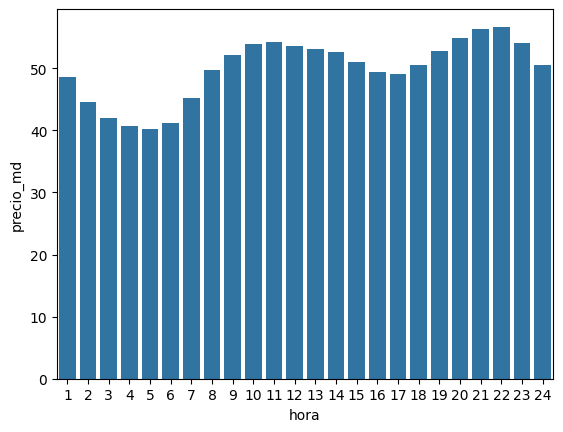

In [28]:
# EJECUTA ESTE CÓDIGO
# Este código muestra cómo se podría crear un gráfico de 24 horas (sin incluir la hora 25)
plt.figure()

plot_precio_hora = sns.barplot(x=precio_hora[precio_hora["hora"] <= 24]["hora"],y=precio_hora[precio_hora["hora"] <= 24]["precio_md"])

display(plot_precio_hora)

<Axes: xlabel='hora', ylabel='precio_md'>

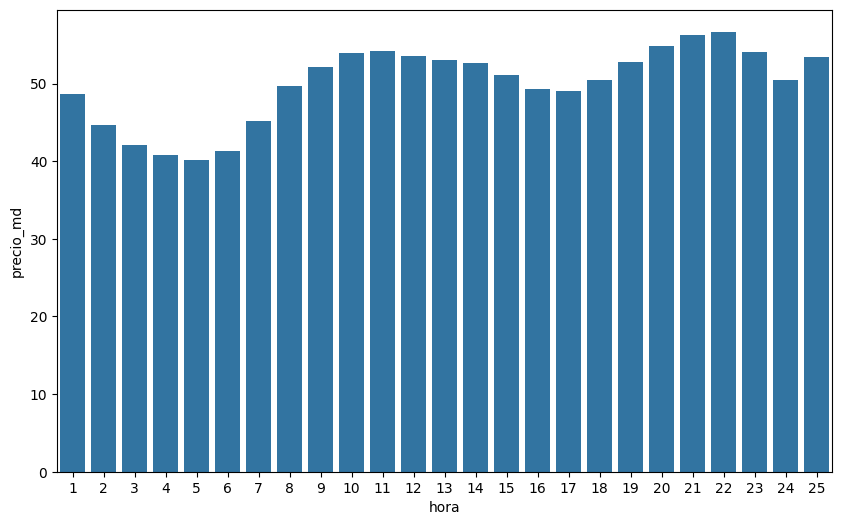

In [29]:
# EJECUTA ESTE CÓDIGO
# Este código muestra cómo se podría crear un gráfico de 25 horas
plt.figure()

plot_precio_hora_25 = sns.barplot(x=precio_hora["hora"], y=precio_hora["precio_md"])

plot_precio_hora_25.figure.set_size_inches(10, 6)

display(plot_precio_hora_25)

Ahora, genera el mismo gráfico (el de 24H o el de 25H) para la previsión de la demanda.

<Axes: xlabel='hora', ylabel='prev_demanda'>

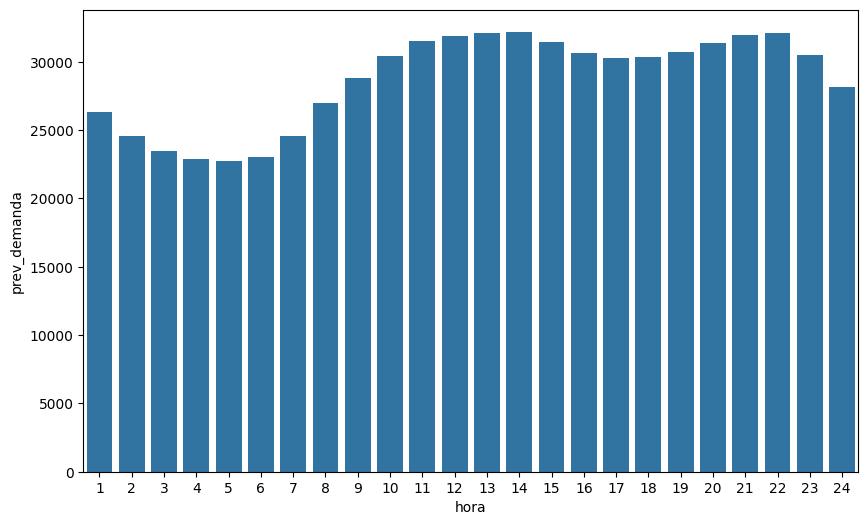

In [30]:
plt.figure()

# Completa el código

# 1. Calculamos la media de preision de demandas por hora
prev_demanda_hora = prev_demanda_pd.groupby(
    "hora", as_index =False)["prev_demanda"].aggregate("mean")

# 2. Preparamos el grafico de barras PARA LAS 24H
plot_prev_demanda_hora_24 = sns.barplot(
    x=prev_demanda_hora[prev_demanda_hora["hora"]<=24]["hora"],
    y=prev_demanda_hora[prev_demanda_hora["hora"]<=24]["prev_demanda"],
    data=prev_demanda_hora)

# 3. Modificamos el tamaño de las figuras del grafico
plot_prev_demanda_hora_24.figure.set_size_inches(10, 6)

# 4. Pintamos el grafico de 24H
display(plot_prev_demanda_hora_24)

Ahora, genera el mismo gráfico (el de 24H o el de 25H) para la previsión eólica.

<Axes: xlabel='hora', ylabel='prev_demanda'>

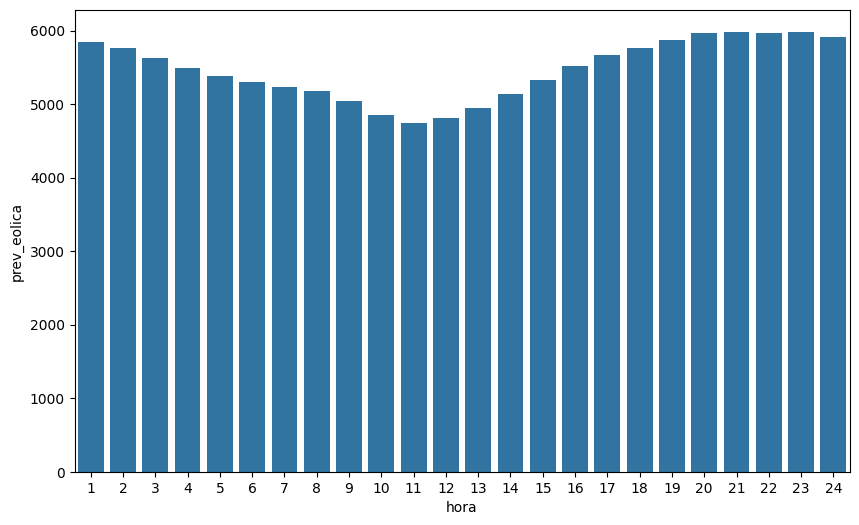

In [31]:
plt.figure()

# Completa el código

# 1. Calculamos la prevision media eolica
prev_eolica_hora = prev_eolica_pd.groupby(
    "hora", as_index =False)["prev_eolica"].aggregate("mean")

# 2. Definimos el grafico de barras para 24H
plot_prev_eolica_hora_24 = sns.barplot(
    x = prev_eolica_hora[prev_eolica_hora["hora"]<=24]["hora"],
    y= prev_eolica_hora[prev_eolica_hora["hora"]<=24]["prev_eolica"],
    data=prev_eolica_hora)

# 3. Modificamos el tamaño de las figuras del grafico
plot_prev_eolica_hora_24.figure.set_size_inches(10, 6)

# 4. Pintamos el grafico de 24H
display(plot_prev_demanda_hora_24)


## **Tarea 3 - Otras visualizaciones gráficas**

En este apartado practicarás la forma de visualizar los datos a través de Pandas y Matplotlib así como Pandas y Plotly, otras librerías con las que podremos implementar gráficos.


***Recuerda que*** para la realización de cada uno de los apartados de este ejercicio podrás hacer uso de los dataframes que habías creado en Pandas en la tarea anterior.

<br>

**Notas:** en otros entornos podrás generar gráficos desde Spark haciendo uso de la función `display()`, sin necesidad de convertir los datos a Pandas. En concreto, en Google Colab esta opción no esta disponible y por ello, será necesario transformar los datos a Pandas y luego, mediante el uso de una librería gráfica generar todos aquellos gráficos que podamos necesitar.

Dicho esto, el código en Spark para estos entornos sería:

*   *`display(precio_md.groupBy("fecha").agg(F.mean(col("precio_md"))) )`*

*   *`display(precio_md.groupBy("hora").agg(F.mean(col("precio_md"))).orderBy("hora") )`*

###  **Apartado 3.A - Matplotlib**

Replica el gráfico de la evolución temporal del precio promedio diario utilizando únicamente la librería Matplotlib y calcula el precio medio para cada una de las fechas.

Deberás hacer uso de un gráfico de líneas y mostrar las columnas precio/previsión demanda/previsión eólica como valor y la fecha como clave para cada uno de los dataframes.

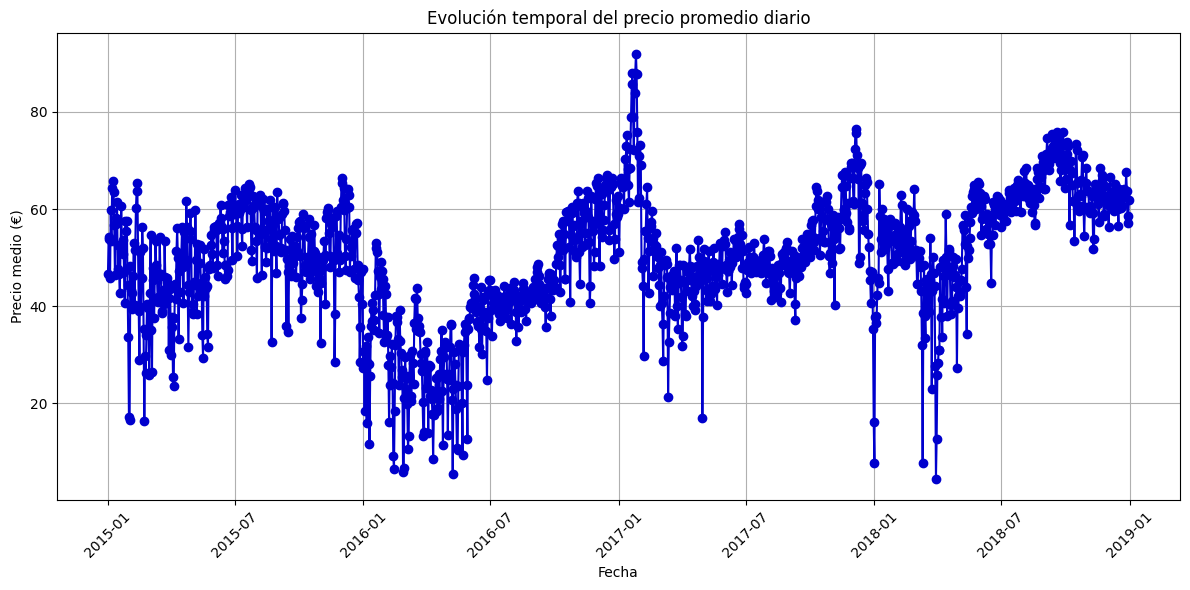

In [32]:
# EJECUTA ESTE CÓDIGO
import matplotlib.pyplot as plt

# Creación del gráfico
plt.figure(figsize=(12, 6))
plt.plot(precio_medio_diario["fecha"], precio_medio_diario["precio_md"], marker='o', linestyle='-', color='mediumblue')

# Configuración de etiquetas y título
plt.title("Evolución temporal del precio promedio diario")
plt.xlabel("Fecha")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Se muestra el gráfico
plt.show()

Replica el gráfico anterior para la previsión de la demanda.

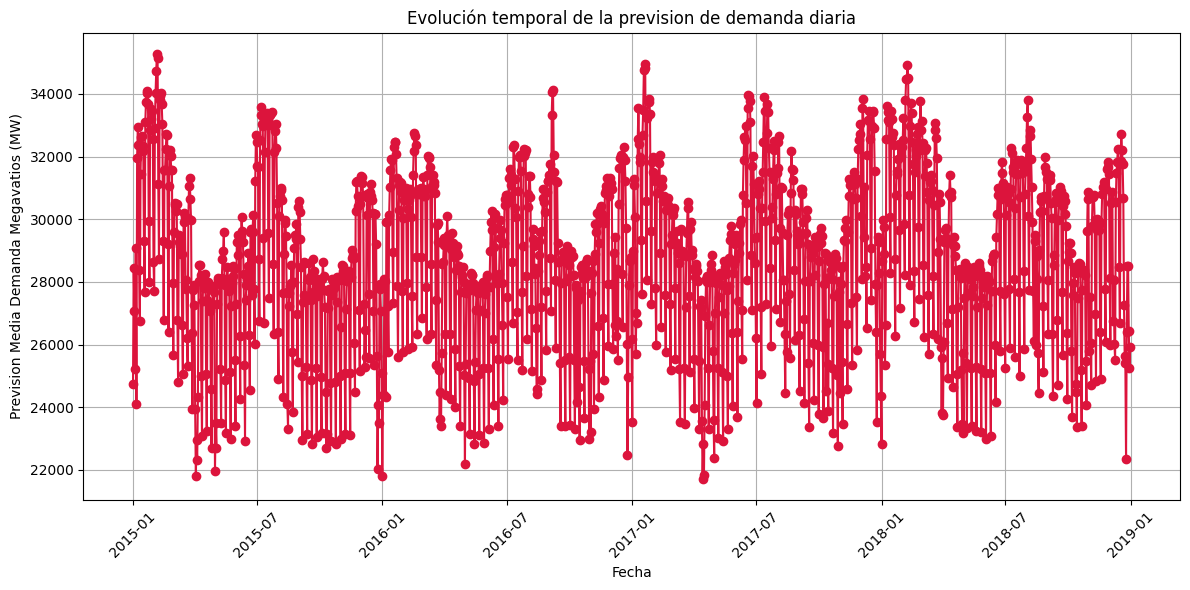

In [33]:
# Completa el código y ajusta el gráfico para la previsión de la demanda

# 1. Generamos la figura para el grafico con las dimensiones del grafico anterior
plt.figure(figsize=(12, 6))

# 2. Generamos el grafico, eligiendo las columnas fecha y prev_de la demanda
  # Replicamos el estilo del grafico anterior, pero cambiamos los colores.
plt.plot(prev_demanda_diario["fecha"],
         prev_demanda_diario ["prev_demanda"],
          marker='o',
          linestyle='-',
          color='crimson')

# 3. Configuramos etiquetas y titulo

plt.title("Evolución temporal de la prevision de demanda diaria")
plt.xlabel("Fecha")
plt.ylabel("Prevision Media Demanda Megavatios (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# 4. # Se muestra el gráfico
plt.show()

Replica el gráfico anterior para la previsión eólica

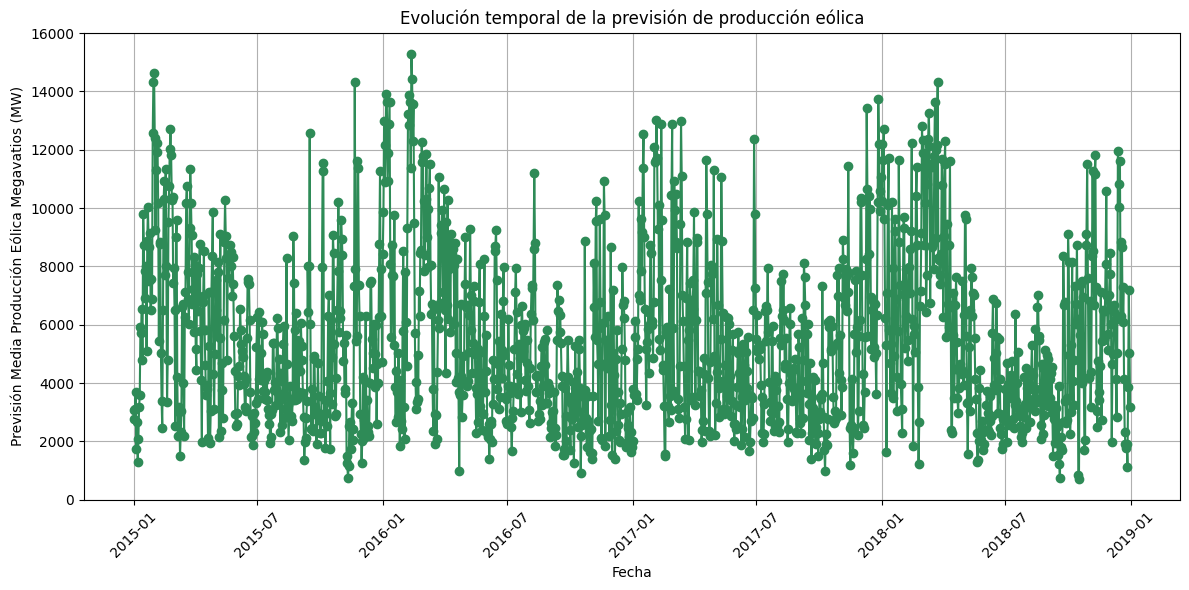

In [34]:
# Completa el código y ajusta el gráfico para la previsión eólica
# 1. Generamos la figura para el grafico con las dimensiones del grafico anterior
plt.figure(figsize=(12, 6))

# 2. Generamos el grafico, eligiendo las columnas fecha y prev_de la demanda
  # Replicamos el estilo del grafico anterior, pero cambiamos los colores.
plt.plot(prev_eolica_diario["fecha"],
         prev_eolica_diario ["prev_eolica"],
          marker='o',
          linestyle='-',
          color='seagreen')

# 3. Configuramos etiquetas y titulo

plt.title("Evolución temporal de la previsión de producción eólica")
plt.xlabel("Fecha")
plt.ylabel("Previsión Media Producción Eólica Megavatios (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# 4. # Se muestra el gráfico
plt.show()

### **Apartado 3.B - Matplotlib**
Replica el gráfico perfil de precio medio horario utilizando únicamente la librería Matplotlib y calcula el precio promedio para cada hora.

Para la realización de este apartado deberás hacer uso de un gráfico barras, donde las columnas precio/previsión demanda/previsión eólica serán el valor y la hora la clave.

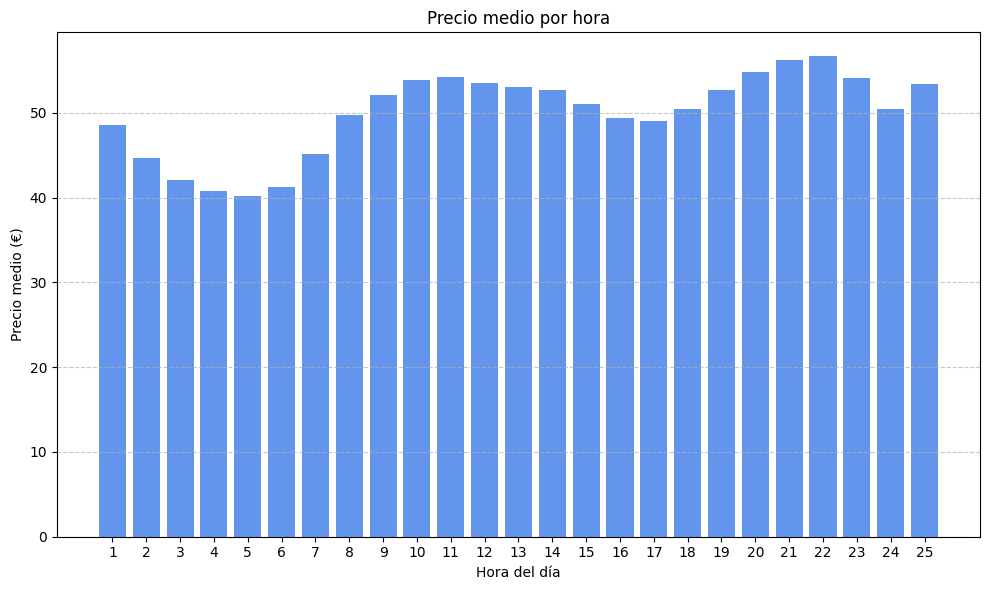

In [35]:
# EJECUTA ESTE CÓDIGO
import matplotlib.pyplot as plt

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Dibujar barras (x = hora, y = precio medio)
plt.bar(precio_hora["hora"], precio_hora["precio_md"], color="cornflowerblue")

# Añadir título y etiquetas
plt.title("Precio medio por hora")
plt.xlabel("Hora del día")
plt.ylabel("Precio medio (€)")

# Asegurar que se vean todas las horas en el eje X
plt.xticks(precio_hora["hora"])

# Añadir líneas de cuadrícula horizontales
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Ajustar diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Replica el gráfico anterior para la previsión de la demanda.

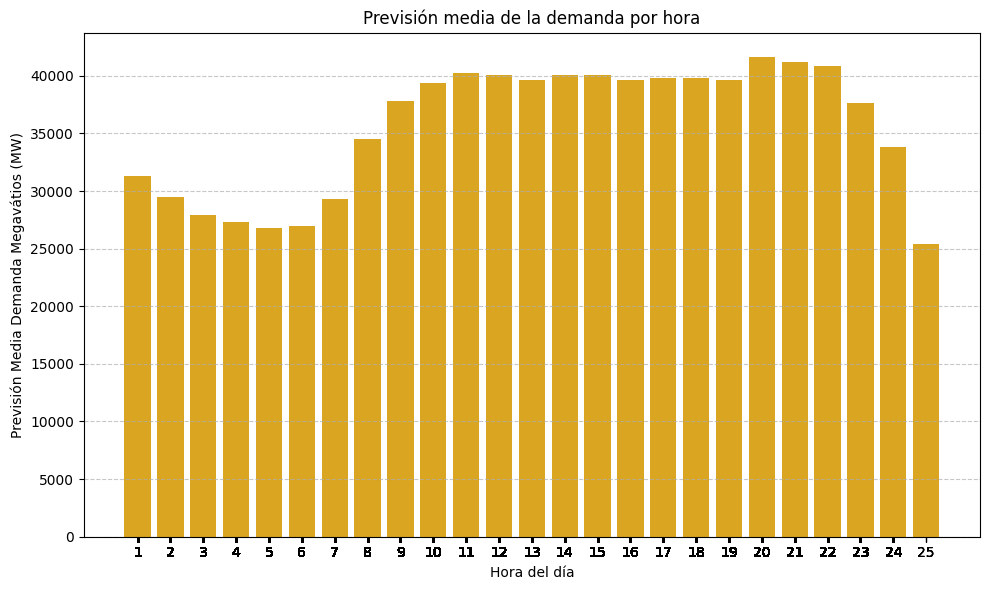

In [36]:
# Completa el código y ajusta el gráfico para la previsión de la demanda
import matplotlib.pyplot as plt

# 1. Crear el gráfico con las mismas dimensiones del anterior
plt.figure(figsize=(10, 6))


# 2. Dibujar grafico de barras para la prevision de la demanda (x = hora, y = prevision de demanda)
  # Cogemos el dataframe de pandas prev_demanda_pd para que se ejecute
  # Cambiamos el color
plt.bar(prev_demanda_pd["hora"],
        prev_demanda_pd["prev_demanda"],
        color="goldenrod")

# 3. Añadimos título y etiquetas
plt.title("Previsión media de la demanda por hora")
plt.xlabel("Hora del día")
plt.ylabel("Previsión Media Demanda Megavátios (MW)")

# 4. Asegurar que se vean todas las horas en el eje X
plt.xticks(prev_demanda_pd["hora"])

# 5. Replicamos el estilo del grafico
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# 6. Mostramos el gráfico
plt.show()

Replica el gráfico anterior para la previsión eólica.

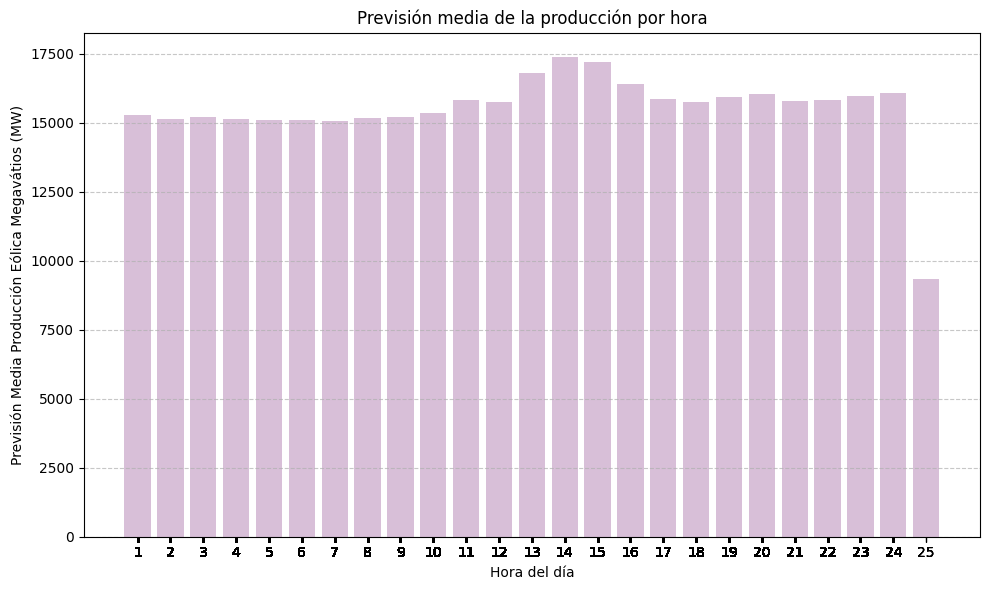

In [37]:
# Completa el código y ajusta el gráfico para la previsión eólica
import matplotlib.pyplot as plt

# 1. Crear el gráfico con las mismas dimensiones del anterior
plt.figure(figsize=(10, 6))

# 2. Dibujar grafico de barras para la prevision de produccion eolica (x = hora, y = prevision produccion eolica)
  # Cogemos el dataframe de pandas prev_eolica_pd para que se ejecute
  # Cambiamos el color
plt.bar(prev_eolica_pd["hora"],
        prev_eolica_pd["prev_eolica"],
        color="thistle")

# 3. Añadimos título y etiquetas
plt.title("Previsión media de la producción por hora")
plt.xlabel("Hora del día")
plt.ylabel("Previsión Media Producción Eólica Megavátios (MW)")

# 4. Asegurar que se vean todas las horas en el eje X
plt.xticks(prev_eolica_pd["hora"])

# 5. Replicamos el estilo del grafico
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# 6. Mostramos el gráfico
plt.show()

### **Apartado 3. C - Plotly**

Replica el gráfico de la evolución temporal del precio promedio diario utilizando únicamente la librería Plotly y calcula el precio medio para cada una de las fechas.

Deberás hacer uso de un gráfico de líneas y mostrar las columnas precio/previsión demanda/previsión eólica como valor y la fecha como clave para cada uno de los dataframes.

In [38]:
# EJECUTA ESTE CÓDIGO
import plotly.express as px

# Crear gráfico de líneas con Plotly
fig = px.line(precio_medio_diario,
              x="fecha",
              y="precio_md",
              title="Evolución temporal del precio promedio diario",
              labels={"fecha": "Fecha", "precio_md": "Precio medio (€)"},
              markers=True,
              template="plotly_white")

# Mostrar gráfico interactivo
fig.show()

Replica el gráfico anterior para la previsión de la demanda

In [39]:
# Completa el código y ajusta el gráfico para la previsión de la demanda

# Crear gráfico de líneas con Plotly
  # Cambio la paleta de colores para distinguirlo del anterior
fig = px.line(prev_demanda_diario,
              x="fecha",
              y="prev_demanda",
              title="Evolución temporal de la demanda diaria de Megavátios",
              labels={"fecha": "Fecha", "prev_demanda": "Previsión Media Demanda Megavátios (MW)"},
              markers=True,
              template="plotly_white",
              color_discrete_sequence=px.colors.qualitative.Antique)

# Mostrar gráfico interactivo
fig.show()

Replica el gráfico anterior para la previsión eólica.

In [40]:
# Completa el código y ajusta el gráfico para la previsión eólica

# Crear gráfico de líneas con Plotly
  # Cambio la paleta de colores para distinguirlo del anterior
fig = px.line(prev_eolica_diario,
              x="fecha",
              y="prev_eolica",
              title="Evolución temporal de la producción eólica de Megavátios",
              labels={"fecha": "Fecha", "prev_demanda": "Previsión Media Producción Eólica Megavátios (MW)"},
              markers=True,
              template="plotly_white",
              color_discrete_sequence=px.colors.qualitative.Prism)

# Mostrar gráfico interactivo
fig.show()

### **Apartado 3.D - Plotly**
Replica el gráfico perfil de precio medio horario utilizando únicamente la librería Plotly y calcula el precio promedio para cada hora.

Para la realización de este apartado deberás hacer uso de un gráfico barras, donde las columnas precio/previsión demanda/previsión eólica serán el valor y la hora la clave.

In [41]:
# EJECUTA ESTE CÓDIGO
# Crear gráfico de barras con Plotly
fig = px.bar(precio_hora,
             x="hora",
             y="precio_md",
             title="Precio medio por hora",
             labels={"hora": "Hora del día", "precio_md": "Precio medio (€)"},
             template="plotly_white"
             )

# Asegurar que las horas estén bien etiquetadas en el eje X
fig.update_layout(xaxis=dict(dtick=1))

# Mostrar gráfico interactivo
fig.show()



Replica el gráfico anterior para la previsión de la demanda

In [42]:
# Completa el código y ajusta el gráfico para la previsión de la demanda

# Crear gráfico de barras con Plotly
  # Cambio el color para que se diferencie del anterior
fig = px.bar(prev_demanda_pd,
             x="hora",
             y="prev_demanda",
             title="Previsión media de demanda de Megavátios (MW) por horas",
             labels={"hora": "Hora del día", "prev_demanda": "Previsión Media Demanda Megavátios (MW)"},
             template="plotly_white",
             color_discrete_sequence=px.colors.qualitative.Antique)

# Asegurar que las horas estén bien etiquetadas en el eje X
  # Quitamos los bordes y opacamos para que se pueda distinguir
fig.update_layout(xaxis=dict(dtick=1))
fig.update_traces(opacity=1, marker_line_width=0)

# Mostrar gráfico interactivo
fig.show()

Replica el gráfico anterior para la previsión eólica.

In [43]:
# Completa el código y ajusta el gráfico para la previsión eólica

# Crear gráfico de barras con Plotly
  # Cambio el color para que se diferencie
fig = px.bar(prev_eolica_pd,
             x="hora",
             y="prev_eolica",
             title="Previsión Media de Producción Eólica de Megavátios (MW) por hora",
             labels={"hora": "Hora del día", "prev_eolica": "Producción Eólica de Megavátios (MW)"},
             template="plotly_white",
             color_discrete_sequence=px.colors.qualitative.Prism)

# Asegurar que las horas estén bien etiquetadas en el eje X
  # Quitamos los bordes y opacamos para que se pueda distinguir
fig.update_layout(xaxis=dict(dtick=1))
fig.update_traces(opacity=1, marker_line_width=0)

# Mostrar gráfico interactivo
fig.show()

## **Tarea 4 - Relación entre variables**

Ahora tienes que explorar y analizar la relación entre las distintas variables que manejamos. Para ello, vas a tener que cruzar los distintos conjuntos de datos que has cargado.

### **Apartado 4.A**
Usando Spark, crea un dataframe resultado de cruzar el dataframe de precios con el dataframe la previsión de demanda y con el dataframe de la previsión eólica.

Para cada fecha y hora deberías obtener una fila con los valores del precio, demanda y eolicidad.

In [44]:
# Completa el código utilizando las funciones de Spark para cruzar dataframes
datos_md = precio_md.join(prev_demanda, on = ["hora","fecha"]).join(prev_eolica, on = ["hora","fecha"])

# Muestra las treinta primeras filas del dataframe resultante (datos_md)
datos_md.show(30)

+----+----------+---------+------------+-----------+
|hora|     fecha|precio_md|prev_demanda|prev_eolica|
+----+----------+---------+------------+-----------+
|   1|2015-01-01|     50.1|       26460|       4996|
|   2|2015-01-01|     48.1|       25369|       4603|
|   3|2015-01-01|    47.33|       23973|       4230|
|   4|2015-01-01|    42.27|       22559|       3976|
|   5|2015-01-01|    38.41|       21603|       3802|
|   6|2015-01-01|    35.72|       21307|       3590|
|   7|2015-01-01|    35.13|       21177|       3420|
|   8|2015-01-01|    36.22|       21266|       3096|
|   9|2015-01-01|     32.4|       21271|       2825|
|  10|2015-01-01|     36.6|       21239|       2605|
|  11|2015-01-01|     43.1|       22631|       2406|
|  12|2015-01-01|    45.14|       23585|       2189|
|  13|2015-01-01|    45.14|       24136|       2119|
|  14|2015-01-01|    47.35|       24926|       2128|
|  15|2015-01-01|    47.35|       25524|       2090|
|  16|2015-01-01|    43.61|       24435|      

### **Apartado 4.B**
Conviérte el dataframe resultante de Spark a Pandas.

In [45]:
datos_md_pd = datos_md.toPandas()

### **Apartado 4.C**
Usando el dataframe de Pandas anterior y Seaborn, completa el código siguiente para pintar un gráfico de distribución conjunta para mostrar la relación entre la previsión de demanda y el precio.

<Figure size 640x480 with 0 Axes>

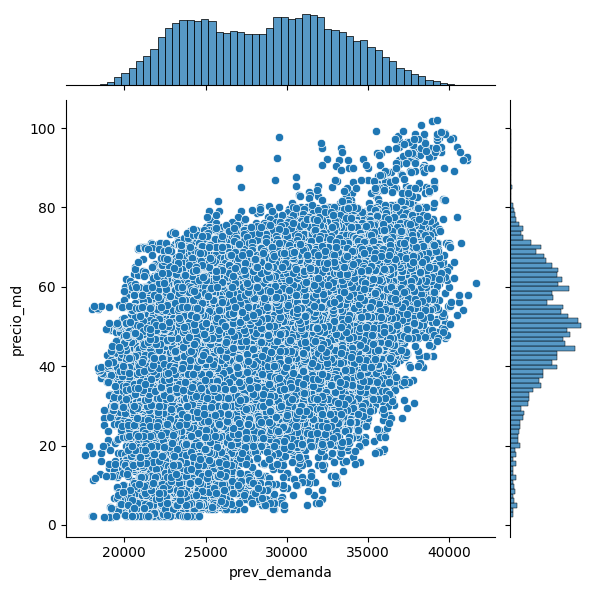

In [46]:
plt.figure()

# Completa el código para crear un gráfico con Seaborn
plot_dem_precio = sns.jointplot(data = datos_md_pd,
                                x = "prev_demanda",
                                y =  "precio_md")

### **Apartado 4.D**
Completa el código siguiente para crear un gráfico similar para la relación entre previsión eólica y el precio usando Pandas y Seaborn.

<Figure size 640x480 with 0 Axes>

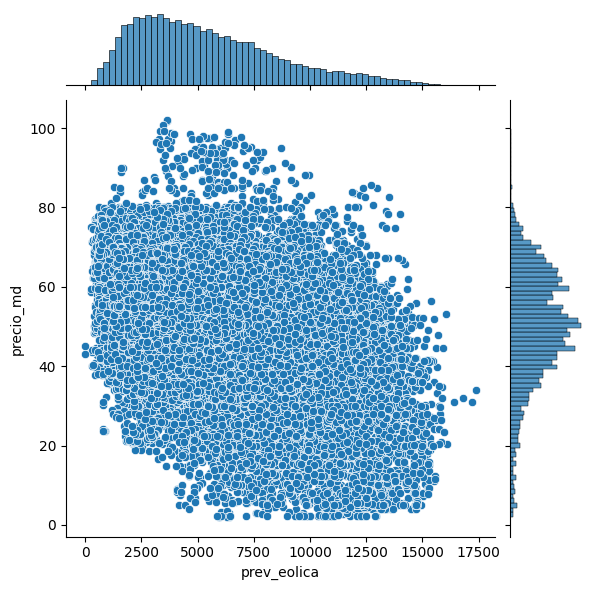

In [47]:
plt.figure()

# Completa el código para crear un gráfico con Seaborn
plot_eol_precio = sns.jointplot( data = datos_md_pd,
                                x = "prev_eolica",
                                y = "precio_md")


### **Apartado 4.E**
Usando el dataframe de Spark y las funciones de Spark que, calcula la correlación entre la previsión de demanda y el precio.

In [48]:
# Completa el código para calcular con Spark la correlación entre la previsión de demanda y el precio
datos_md.select(F.round(F.corr("prev_demanda","precio_md"), 2)).show()

+---------------------------------------+
|round(corr(prev_demanda, precio_md), 2)|
+---------------------------------------+
|                                   0.47|
+---------------------------------------+



### **Apartado 4.F**
Repite la operación pero ahora para calcular la correlación entre la previsión eólica y el precio

In [49]:
# Completa el código para calcular con Spark la correlación entre la previsión de generación eólica y el precio
datos_md.select(F.round(F.corr("prev_eolica","precio_md"), 2)).show()

+--------------------------------------+
|round(corr(prev_eolica, precio_md), 2)|
+--------------------------------------+
|                                 -0.43|
+--------------------------------------+



## **Tarea 5 - Modelos estadísticos para predecir el precio de mercado (del día siguiente)**

### **Apartado 5.A**
Usando Spark, construye y entrena un modelo lineal de predicción del precio
usando la prevision de demanda y de generacion eolica como predictores.

Utiliza el conjunto total de datos, dividiéndolo aleatóriamente al 80% para entrenamiento y 20% para validación.

In [109]:
import numpy as np
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# Configura las variables predictoras
assembler = VectorAssembler(inputCols = ["prev_demanda", "prev_eolica"], outputCol = "prev_ML")

# Empaqueta los vectores de variables predictoras
datos_md_trf = assembler.transform(datos_md)

# Divide en conjuntos de entrenamiento y test al 80%-20%
datos_md_train, datos_md_test = datos_md_trf.randomSplit([0.8,0.2])

# Crea el modelo
lr = LinearRegression(featuresCol= "prev_ML", labelCol = "precio_md")

# Entrena el modelo
lr_model = lr.fit(datos_md_train)

# Muestra la cantidad de elementos en el conjunto de entrenamiento
print(f"La cantidad de elementos del conjunto de entrenamiento consta de {datos_md_train.count()} elementos")

La cantidad de elementos del conjunto de entrenamiento consta de 28024 elementos


### **Apartado 5.B**
Utilizando la función siguiente que ya vimos en la Unidad de Spark, imprime los coeficientes del modelo ajustado. Muestra también la raiz del error cuadrático medio.

In [110]:
def print_model_results(model, feature_names):
    coefs = np.append(model.intercept, model.coefficients.values)
    p_values = model.summary.pValues
    t_values = model.summary.tValues

    print("Variable\tCoefficient\tp-Value.\tt-Value.")
    for model_res in zip(feature_names, coefs,
                         p_values, t_values):
        print("%s\t%f\t%f\t%f" % model_res)

    print("RMSE : %f" % model.summary.rootMeanSquaredError)
    print("r2 : %f" % model.summary.r2)


# Completa los parámetros para llamar a la función
print_model_results(lr_model, "prediction" )

Variable	Coefficient	p-Value.	t-Value.
p	16.153695	0.000000	108.979287
r	0.001569	0.000000	-98.649937
e	-0.002069	0.000000	37.607785
RMSE : 11.064164
r2 : 0.425702


### **Apartado 5.C**
Con el modelo ajustado, calcula la predicción sobre el conjunto de validación.

In [111]:
# Calcula la predicción sobre el conjunto de validación
lr_predict = lr_model.transform(datos_md_test)

# Muestra la predicción
lr_predict.show()

+----+----------+---------+------------+-----------+-----------------+------------------+
|hora|     fecha|precio_md|prev_demanda|prev_eolica|          prev_ML|        prediction|
+----+----------+---------+------------+-----------+-----------------+------------------+
|   1|2015-01-04|    39.82|       25278|       4080| [25278.0,4080.0]| 47.37831013935023|
|   1|2015-01-08|     61.5|       28966|       1477| [28966.0,1477.0]| 58.55199370034492|
|   1|2015-01-11|    44.39|       27151|       5283| [27151.0,5283.0]|47.828158729186384|
|   1|2015-01-30|     20.0|       29181|      15113|[29181.0,15113.0]|30.672736008946018|
|   1|2015-02-15|     27.5|       27252|      12114|[27252.0,12114.0]| 33.85142923564514|
|   1|2015-02-17|     39.1|       27992|       8821| [27992.0,8821.0]|  41.8267922667543|
|   1|2015-02-24|     12.4|       27639|      13715|[27639.0,13715.0]| 31.14581477894968|
|   1|2015-03-04|    43.99|       26354|       3849| [26354.0,3849.0]| 49.54481555299115|
|   1|2015

### **Apartado 5.D**
Evalúa la predicción: obtén la raiz del error cuadrático medio.

In [112]:
from pyspark.ml.evaluation import RegressionEvaluator

# Configura el evaluador de resultados para calcular la raiz del error cuadrático medio
lr_evaluator = RegressionEvaluator(predictionCol= "prediction", labelCol="precio_md",metricName = "rmse")

# Imprime el error calculado
print(f"El error cuadrático medio es {lr_evaluator.evaluate(lr_predict)}")

El error cuadrático medio es 11.255286145935598


## **Tarea 6 - Entrenamiento del modelo con datos recientes**

Vamos a usar solamente tres meses de datos para entrenar el modelo y después predecir los precios del mes siguiente.

### **Apartado 6.A**
Entrena el modelo seleccionando los datos de septiembre a noviembre (inclusive) de 2018.  
Selecciona los datos de diciembre de 2018 como conjunto sobre el que predecir y testear el modelo.

In [113]:
# Selecciona los datos de septiembre a noviembre de 2018 para entrenar y muestra los datos
datos_md_train_2 = datos_md_trf.where(F.col("fecha").between("2018-09-01", "2018-11-30"))
print(" Este bloque corresponde a los datos de entrenamiento")
datos_md_train_2.show(5)
print(40*"--")

# Selecciona los datos de diciembre de 2018 para predecir y validar el modelo y muestra los datos
datos_md_test_2 = datos_md_trf.where(F.col("fecha").between("2018-12-01", "2019-01-01"))
print(" Este bloque corresponde a los datos de testeo")
datos_md_test_2.show(5)
print(40*"--")

# Ajusta de nuevo el modelo usando estos datos de entrenamiento
lr_model_2 = lr.fit(datos_md_train_2)

 Este bloque corresponde a los datos de entrenamiento
+----+----------+---------+------------+-----------+----------------+
|hora|     fecha|precio_md|prev_demanda|prev_eolica|         prev_ML|
+----+----------+---------+------------+-----------+----------------+
|   1|2018-09-01|    67.49|       28124|       7146|[28124.0,7146.0]|
|   2|2018-09-01|    61.91|       26581|       6695|[26581.0,6695.0]|
|   3|2018-09-01|    59.28|       25297|       6371|[25297.0,6371.0]|
|   4|2018-09-01|    58.07|       24523|       6355|[24523.0,6355.0]|
|   5|2018-09-01|    57.57|       24033|       5807|[24033.0,5807.0]|
+----+----------+---------+------------+-----------+----------------+
only showing top 5 rows
--------------------------------------------------------------------------------
 Este bloque corresponde a los datos de testeo
+----+----------+---------+------------+-----------+----------------+
|hora|     fecha|precio_md|prev_demanda|prev_eolica|         prev_ML|
+----+----------+-------

### **Apartado 6.B**
Predice sobre los datos de diciembre.
Compara los resultados con los obtenidos entrenando con el subconjunto aleatorio del total de datos.
¿Es mejor o peor que usando todos los datos?

In [114]:
# Imprime los coeficientes del modelo ajustado
print_model_results(lr_model_2, "prediction")

Variable	Coefficient	p-Value.	t-Value.
p	39.395702	0.000000	48.903125
r	0.001214	0.000000	-42.091587
e	-0.001543	0.000000	52.516469
RMSE : 5.008614
r2 : 0.669485


In [115]:
# Predice los precios usando los nuevos datos de validación y muestra la predicción
lr_predict_2.show()

+----+----------+---------+------------+-----------+----------------+------------------+
|hora|     fecha|precio_md|prev_demanda|prev_eolica|         prev_ML|        prediction|
+----+----------+---------+------------+-----------+----------------+------------------+
|   1|2018-12-01|     67.2|       27711|       6852|[27711.0,6852.0]|62.452024299770954|
|   2|2018-12-01|    63.34|       25620|       7049|[25620.0,7049.0]| 59.61024710287576|
|   3|2018-12-01|    54.89|       24131|       7247|[24131.0,7247.0]| 57.49754224137735|
|   4|2018-12-01|    55.29|       23404|       7152|[23404.0,7152.0]| 56.76183922111973|
|   5|2018-12-01|    52.01|       23020|       7187|[23020.0,7187.0]|  56.2417812756893|
|   6|2018-12-01|    52.01|       23021|       7601|[23021.0,7601.0]| 55.60404656691643|
|   7|2018-12-01|     55.9|       23918|       7562|[23918.0,7562.0]| 56.75287900351317|
|   8|2018-12-01|     57.0|       25467|       7415|[25467.0,7415.0]|   58.859691675064|
|   9|2018-12-01|    

In [116]:
# Calcula e imprime la raiz del error cuadrático medio de la nueva predicción
print(f"El error cuadrático medio es {lr_evaluator.evaluate(lr_predict_2)}")

# ¿Es mejor o peor que usando todos los datos?
print( "\nEl error cuadratico medio del 2º modelo es mejor, ya que esta mas proximo a 0, que el del primer modelo",
      f"\nEn el primer modelo el error cuadratico medio era de {lr_evaluator.evaluate(lr_predict)}")

El error cuadrático medio es 5.079766862213614

El error cuadratico medio del 2º modelo es mejor, ya que esta mas proximo a 0, que el del primer modelo 
En el primer modelo el error cuadratico medio era de 11.255286145935598


# **Exportar el cuaderno de trabajo**

Recuerda que una vez hayas finalizado el ejercicio será necesario que lo descargues en formato `.ipynb` y después, que lo imprimas en formato `.pdf`.

<br>

En la barra superior del cuaderno verás un acceso al menú `Archivo`. Si pulsas, se desplegarán varias opciones, entre las que encontrarás el submenú `Descargar`.  

<br>

Aquí encontrarás dos opciones o formatos para guardar tu cuaderno:
- `.ipynb` : exporta el contenido al formato de cuadernos de IPython/Jupyter; de esta forma, puedes abrir el fichero con Jupyter y trabajar en tu propio ordenador. Es posible que fragmentos del código no funcionen correctamente.

- `.py` : exporta el contenido en formato de fichero fuente de Python. Las celdas de código se mantienen como código Python y las celdas de texto se transforman en comentarios.

De forma adicional, si accedes nuevamente al menú `Archivo` y seleccionas la opción `Imprimir` podrás descargar el archivo en formato PDF.

<br>

__Estos ficheros guardados son los que tienes que enviar como resolución del ejercicio final para poder evaluarlo.__

<br>

> **Recuerda**. Antes de exportarlo, modifica el nombre o título del cuaderno siguiendo las instrucciones indicadas en el enunciado.

> Para ello, abre el menú `Archivo` en la barra superior y selecciona la opción `Cambiar nombre`.  
  

***Recomendación final***. Una vez que tengas terminado el ejercicio y antes de exportarlo, te recomendamos que ejecutes todo el código desde cero para asegurarte de que no hay errores.